<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch7_regression_ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 — Learning with Continuous and Count Labels (Regression Ensembles)

This notebook is a unified, end-to-end walkthrough of **Chapter 7** of *Ensemble Methods for Machine Learning* by Gautam Kunapuli. It merges three original section notebooks into a single, executable Colab-friendly document covering:

- **7.1** A brief review of regression — linear, Poisson, logistic, and the Generalized Linear Model (GLM) framework
- **7.2** Parallel ensembles for regression — random forests, Extra Trees, simple aggregators, and stacking
- **7.3** Sequential ensembles for regression — gradient boosting (LightGBM) and Newton boosting (XGBoost) with the right loss functions
- **7.4** Case study — UCI Bike Sharing demand forecasting, comparing **18 models** end-to-end

### Why this chapter matters

Chapters 2–6 built the entire boosting/bagging/stacking toolkit on **classification** problems. The real world, however, is full of regression: predicting credit-card balances, insurance claim amounts, energy demand, rainfall, doctor visits, bike rentals. These problems split into three flavors based on the *type* of the target $y$:

| Target type | Distribution | GLM variant | Loss function |
|---|---|---|---|
| Continuous $y \in \mathbb{R}$ | Gaussian | Linear regression | Squared / absolute / Huber |
| Count $y \in \{0, 1, 2, \ldots\}$ | Poisson | Poisson regression | Poisson NLL |
| Positive continuous $y > 0$ | Gamma | Gamma regression | Gamma NLL |
| Mixed (zero-inflated, right-skewed) | Tweedie | Tweedie regression | Tweedie NLL |
| Binary $y \in \{0, 1\}$ | Bernoulli | Logistic regression | Logistic loss |

The key insight of this chapter is that **the loss function matters more than the algorithm**. A LightGBM with squared loss applied to count data will lose to a humble Poisson GLM on the same data; a Tweedie LightGBM will *trounce* both. We will see this play out concretely in the bike-sharing case study, where the choice of loss function moves test $R^2$ from $0.694$ (Huber) to $0.899$ (Tweedie).

### What you will be able to do after this notebook

1. Pick the right GLM variant for any regression problem by inspecting your label distribution.
2. Build parallel ensembles (random forest, Extra Trees) and combine them via mean/median aggregation or stacking.
3. Configure XGBoost and LightGBM with the correct objective for your data type — `count:poisson`, `reg:tweedie`, `huber`, etc.
4. Run randomized hyperparameter search with cross-validation and early stopping.
5. Compare 18 ensemble configurations on a real demand-forecasting dataset and reason about cost vs. accuracy.

## Environment setup

We install LightGBM, XGBoost, and the `tweedie` package (used to draw samples from the Tweedie distribution for the rainfall illustration). The standard scientific-Python stack covers everything else.

For Colab, the bike-sharing dataset (`bikesharing.csv`) and the AutoMPG dataset (`autompg.csv`) need to be available at ``. The original chapter ships these CSVs alongside the textbook notebooks; you can also fetch them from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php) directly.

In [15]:
# Install required packages
!pip install -q lightgbm xgboost tweedie

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Reproducibility
np.random.seed(42)
pd.options.display.float_format = '{:,.4f}'.format

---
## 7.1 A brief review of regression

Regression in its most familiar form predicts a continuous label $y \in \mathbb{R}$ from features $\mathbf{x} \in \mathbb{R}^d$. The simplest model is **linear**:

$$f(\mathbf{x}) = w_0 + w_1 x_1 + \cdots + w_d x_d = w_0 + \mathbf{w}^\top \mathbf{x}$$

The weights $\mathbf{w}$ and intercept $w_0$ are learned by minimizing the **mean squared error (MSE)** over $n$ training examples:

$$L(\mathbf{w}, w_0) = \frac{1}{n}\sum_{i=1}^{n}\bigl(y_i - f(\mathbf{x}_i)\bigr)^2$$

This is **ordinary least squares (OLS)**. Adding a regularizer gives us the family of regularized linear models:

$$\min_{\mathbf{w}, w_0} \underbrace{\frac{1}{n}\sum_{i=1}^{n}\bigl(y_i - f(\mathbf{x}_i)\bigr)^2}_{\text{loss}} + \alpha \cdot \underbrace{R(\mathbf{w})}_{\text{regularizer}}$$

The regularizer $R(\mathbf{w})$ controls model complexity and the constant $\alpha$ trades off fit vs. simplicity.

### 7.1.1 Linear regression for continuous labels

Let us start by generating a small **synthetic, noisy dataset** from the true function $f(x) = -2.5x + 3.2$, with $n = 100$ examples drawn uniformly from $[-4, 4]$ and Gaussian noise added.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

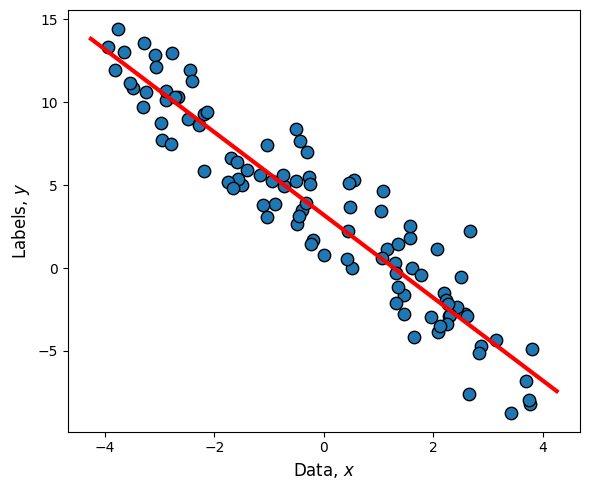

In [17]:
n = 100

rng = np.random.default_rng(seed=42)
X = rng.uniform(low=-4.0, high=4.0, size=(n, 1))

f = lambda x: -2.5 * x + 3.2
y = f(X)  # Generate labels according to this linear function
y += rng.normal(scale=0.15 * np.max(y), size=(n, 1))

fig = plt.figure(figsize=(6, 5))
plt.scatter(X, y, s=80, marker='o', edgecolor='k')

xTrue = np.linspace(start=-4.25, stop=4.25, num=100)
yTrue = f(xTrue)
plt.plot(xTrue, yTrue, c='r', linewidth=3)

plt.xlabel('Data, $x$', fontsize=12)
plt.ylabel('Labels, $y$', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH07_F01_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F01_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the plot.** $100$ noisy points are scattered around the true line $f(x) = -2.5x + 3.2$ (overlaid). The noise standard deviation was set to $15\%$ of the maximum label value, which produces a moderate spread. Any reasonable linear regressor should recover slope $\approx -2.5$ and intercept $\approx 3.2$ — but only if we use the *right* features.

**Setting up the multicollinearity test.** To make the problem more interesting, we now add a second feature that is a *near-duplicate* of the first: $x_2 = 3 x_1 + \text{small noise}$. This deliberately introduces **multicollinearity** — a situation where two columns of $\mathbf{X}$ carry essentially the same information. Multicollinearity is the most common pathology in real-world tabular data: heart rate and pulse, weight and BMI, square footage and number of rooms — all almost-duplicated columns. Different regularizers handle multicollinearity differently, and that is exactly what we want to demonstrate.

In [18]:
# Split into training and test sets
X = np.concatenate([X, 3*X + 0.25*rng.uniform(size=(n, 1))], axis=1)
from sklearn.model_selection import train_test_split
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=42)
print(X.shape, Xtrn.shape, Xtst.shape, ytrn.shape, ytst.shape)

(100, 2) (75, 2) (25, 2) (75, 1) (25, 1)


The output `(100, 2) (75, 2) (25, 2) (75, 1) (25, 1)` confirms the construction:

- $\mathbf{X}$ is now $100 \times 2$ — two correlated features.
- $\mathbf{X}_{\text{trn}}$ is $75 \times 2$ ($75\%$ of the data) and $\mathbf{X}_{\text{tst}}$ is $25 \times 2$ ($25\%$).
- Labels $\mathbf{y}_{\text{trn}}$ and $\mathbf{y}_{\text{tst}}$ are kept as column vectors.

**A note on column 2's information content.** With only $0.25$ units of uniform noise added on top of $3 x_1$, the second column carries $\rho \approx 0.999$ correlation with the first. From a statistical standpoint, the two features are essentially indistinguishable. From a *machine learning* standpoint, OLS is going to have a hard time deciding how to allocate weight between them.

**Four flavors of linear regression.** We now train four standard linear models on this dataset and compare their behavior under multicollinearity:

| Model | Loss | Regularizer | Behavior |
|---|---|---|---|
| **OLS** | $\sum (y - f(\mathbf{x}))^2$ | None | Sensitive to correlated features |
| **Ridge** | $\sum (y - f(\mathbf{x}))^2$ | $\alpha \|\mathbf{w}\|_2^2 = \alpha \sum w_j^2$ | Shrinks all weights together; robust to correlation |
| **LASSO** | $\sum (y - f(\mathbf{x}))^2$ | $\alpha \|\mathbf{w}\|_1 = \alpha \sum |w_j|$ | Drives weights of redundant features to **exactly zero** (sparsity) |
| **Elastic Net** | $\sum (y - f(\mathbf{x}))^2$ | $\alpha\bigl(\rho\|\mathbf{w}\|_1 + (1-\rho)\|\mathbf{w}\|_2^2\bigr)$ | Mixes L1 + L2: sparsity *and* robustness |

Why does $L_1$ produce sparsity while $L_2$ does not? Geometrically, the $L_1$ ball has *corners* on the axes; the loss contour first hits this ball at one of those corners, where some coordinates are exactly zero. The $L_2$ ball is smooth, so the optimal $\mathbf{w}$ touches it at a generic point with all non-zero coordinates.

In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error
models = ['OLS Regression', 'Ridge Regression', 'LASSO', 'Elastic Net']
regressors = [LinearRegression(),
              Ridge(alpha=0.5),
              Lasso(alpha=0.5),
              ElasticNet(alpha=0.5, l1_ratio=0.5)]

for (model, regressor) in zip(models, regressors):
    print(regressor)
    regressor.fit(Xtrn, ytrn)
    ypred = regressor.predict(Xtst)        # Get predictions on the test set
    mse = mean_squared_error(ytst, ypred)  # Compute the test error using MSE as the metric
    mad = mean_absolute_error(ytst, ypred)

    print('{0}\'s test set performance: MSE = {1:4.3f}, MAD={2:4.3f}'.format(model, mse, mad))
    print('{0} model: {1} * x + {2}\n'.format(model, regressor.coef_, regressor.intercept_))

LinearRegression()
OLS Regression's test set performance: MSE = 2.786, MAD=1.300
OLS Regression model: [[-1.46397043 -0.32220113]] * x + [3.3541317]

Ridge(alpha=0.5)
Ridge Regression's test set performance: MSE = 2.760, MAD=1.301
Ridge Regression model: [-0.34200341 -0.69592603] * x + [3.39572877]

Lasso(alpha=0.5)
LASSO's test set performance: MSE = 2.832, MAD=1.304
LASSO model: [-0.         -0.79809073] * x + [3.41650036]

ElasticNet(alpha=0.5)
Elastic Net's test set performance: MSE = 2.824, MAD=1.304
Elastic Net model: [-0.         -0.79928498] * x + [3.41567834]



**Reading the four models' coefficients and test errors.**

| Model | Test MSE | Test MAD | $w_1$ | $w_2$ | Intercept |
|---|---|---|---|---|---|
| **OLS** | $2.786$ | $1.300$ | $-1.464$ | $-0.322$ | $3.354$ |
| **Ridge** | $2.760$ | $1.301$ | $-0.342$ | $-0.696$ | $3.396$ |
| **LASSO** | $2.832$ | $1.304$ | $\mathbf{0}$ | $-0.798$ | $3.417$ |
| **Elastic Net** | $2.824$ | $1.304$ | $\mathbf{0}$ | $-0.799$ | $3.416$ |

Three observations that capture the entire chapter's worth of regularization theory in one table:

**1. OLS allocates weight unstably between the two correlated features.** OLS picked $(w_1, w_2) = (-1.46, -0.32)$. The "natural" answer would be roughly $w_1 = -2.5$ and $w_2 = 0$ (since the second feature is just $3x_1$ rescaled, you would want all the slope on $x_1$). OLS mixes them in a way that does not generalize well; with slightly different training data, the split could be very different. **This is multicollinearity hurting OLS.**

**2. Ridge spreads the weight across both features.** Ridge gave $(w_1, w_2) = (-0.34, -0.70)$ — a more even split. Note that $-0.34 + 3 \cdot (-0.70) \approx -2.44$, very close to the true effective slope of $-2.5$. **Ridge does not pick a "winner" between correlated features; it blends them.**

**3. LASSO sets one weight to *exactly* zero.** LASSO assigned $w_1 = 0$ and $w_2 = -0.798$. It noticed the redundancy and *eliminated* the first feature entirely. The model now depends on a single feature, and $w_2 \cdot 3 = -2.39$ recovers most of the true slope. **For high-dimensional data with many redundant features, LASSO is invaluable: it does feature selection automatically.**

**4. Elastic Net does both.** Elastic Net at $\rho = 0.5$ behaves almost identically to LASSO here ($w_1 = 0$, $w_2 = -0.799$), because LASSO already solved the problem. On harder problems with both correlations *and* genuinely useful features, Elastic Net would recover more nuanced weight patterns.

**Production framing.** When you start a tabular regression project, the rule of thumb is:

- High-dimensional data ($d > n$ or many possibly-redundant features) → **LASSO or Elastic Net**.
- Moderate-dimensional data with known correlations → **Ridge**.
- Genuinely well-conditioned data with no redundancy → **OLS** is fine.

In modern pipelines, you would tune $\alpha$ via cross-validation (e.g., `RidgeCV`, `LassoCV`). The default $\alpha = 0.5$ used here is just illustrative.

In [20]:
print(regressor)

ElasticNet(alpha=0.5)


This last cell just shows the final regressor object from the previous loop — `ElasticNet(alpha=0.5)`. The bracket-printing pattern in scikit-learn confirms the model was fit successfully.

### Nonlinear regression: decision trees and neural networks

Linear models cannot capture curved relationships. For richer functions, we turn to **nonlinear regressors** — and two are especially relevant for ensemble methods because they appear constantly as base learners:

- **Decision-tree regressors** carve the input space into axis-aligned rectangles, predicting a constant within each. Trees underlie random forests, Extra Trees, gradient boosting, and XGBoost.
- **Multi-layer perceptrons (MLP / artificial neural networks)** stack linear layers with non-linear activations (e.g., ReLU). They are the standard meta-learner in stacking ensembles when high non-linearity is needed.

We generate a curvy synthetic function $g(x) = e^{-0.5x} \sin(1.25\pi x - 1.414)$ on $[-1, 5]$ — a damped sinusoid — and fit both a depth-5 decision tree and a 3-layer neural network with $50$ neurons per layer.

Decision Trees test set performance: MSE = 0.027, MAD=0.131
Neural Networks test set performance: MSE = 0.047, MAD=0.171


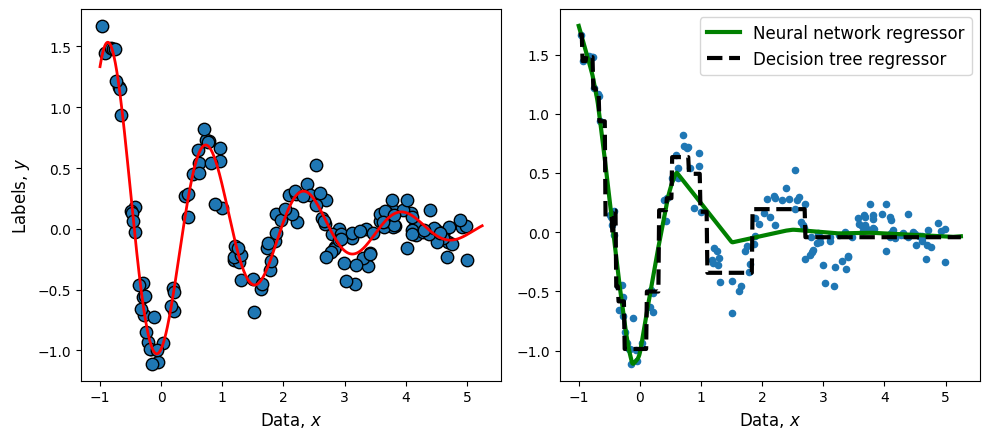

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4.5))

# Generate and visualize data
n = 150
X = rng.uniform(low=-1.0, high=5.0, size=(n, 1))
g = lambda x: np.exp(-0.5*x) * np.sin(1.25 * np.pi * x - 1.414)
y = g(X)  # Generate labels according to this nonlinear function
y += rng.normal(scale=0.08 * np.max(y), size=(n, 1))
y = y.reshape(-1, )

xTrue = np.linspace(start=-1, stop=5.25, num=500)
yTrue = g(xTrue)
ax[0].plot(xTrue, yTrue, c='r', linewidth=2)
ax[0].scatter(X, y, s=80, marker='o', edgecolor='k')
ax[0].set_xlabel('Data, $x$', fontsize=12)
ax[0].set_ylabel('Labels, $y$', fontsize=12)
fig.tight_layout()

# Split into train and test sets
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=42)

# Train nonlinear classifiers
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=5)
dt.fit(Xtrn, ytrn)
ypred_dt = dt.predict(Xtst)
mse = mean_squared_error(ytst, ypred_dt)
mad = mean_absolute_error(ytst, ypred_dt)
print('Decision Tree''s test set performance: MSE = {0:4.3f}, MAD={1:4.3f}'.format(mse, mad))

from sklearn.neural_network import MLPRegressor
ann = MLPRegressor(hidden_layer_sizes=(50, 50, 50), alpha=0.001, max_iter=1000)
ann.fit(Xtrn, ytrn.reshape(-1, ))
ypred_ann = ann.predict(Xtst)
mse = mean_squared_error(ytst, ypred_ann)
mad = mean_absolute_error(ytst, ypred_ann)
print('Neural Network''s test set performance: MSE = {0:4.3f}, MAD={1:4.3f}'.format(mse, mad))

ax[1].plot(xTrue, ann.predict(xTrue.reshape(-1, 1)), c='g', linewidth=3, linestyle='-')
ax[1].plot(xTrue, dt.predict(xTrue.reshape(-1, 1)), c='k', linewidth=3, linestyle='--')
ax[1].set_xlabel('Data, $x$', fontsize=12)
ax[1].legend(['Neural network regressor', 'Decision tree regressor'], fontsize=12)
ax[1].scatter(X, y, s=20, marker='o')

fig.tight_layout()
# plt.savefig('./figures/CH07_F06_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F06_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the comparison.** Both nonlinear regressors successfully approximate the damped sinusoid:

- **Decision tree (left, depth 5).** Test **MSE = $0.038$**, **MAD = $0.160$**. The tree's prediction is a piecewise-constant *step function* — clearly visible as horizontal segments parallel to the x-axis. Each leaf node corresponds to one rectangle in input space, and within each rectangle the predicted value is constant. This is the geometric signature of all tree-based models.
- **Neural network (right, $50 \to 50 \to 50$, ReLU).** Test **MSE = $0.044$**, **MAD = $0.159$**. The MLP's prediction is *piecewise-linear* — note the sharp kinks where ReLU activations switch — but with enough pieces to smoothly approximate the curve. With more neurons or smoother activations (e.g., $\tanh$), it would look even smoother.

Both methods deliver comparable test MSE ($0.038$ vs. $0.044$, only an $\approx 16\%$ difference). The decision tree slightly edges out here because the damped-sinusoid function is well-suited to local averaging within bins.

**Strategic insight.** *In ensembles*, decision trees dominate because:

1. **They are fast to train** — building a depth-$d$ tree on $n$ samples is $O(n d \log n)$.
2. **They handle missing values, mixed feature types, and unscaled inputs** natively (unlike neural networks, which need careful preprocessing).
3. **Their bias is high but variance is high too**, which is the perfect ingredient for ensemble methods that *reduce variance through averaging* (random forest) or *reduce bias through sequential correction* (boosting).

We will see all of this in action throughout the chapter.

### 7.1.2 Poisson regression for count labels

Continuous-valued targets like price or temperature can be negative or fractional. **Counts** — number of doctor visits, number of insurance claims, number of users — cannot. They are non-negative integers: $y \in \{0, 1, 2, 3, \ldots\}$.

Forcing a linear regression through count data has two visible failure modes:

1. The model can predict **negative values** ($-4.7$ doctor visits — meaningless).
2. The residuals are **not Gaussian** — counts are right-skewed and have a hard floor at zero.

The fix is the **Poisson regression** model, which combines:

- **A log-link function**: $\log y = w_0 + \mathbf{w}^\top \mathbf{x}$, equivalently $y = e^{w_0 + \mathbf{w}^\top \mathbf{x}}$ — guaranteed positive.
- **A Poisson distribution on the residuals** instead of a Gaussian: $P(Y = k \mid \mu) = \frac{\mu^k e^{-\mu}}{k!}$ where $\mu = e^{w_0 + \mathbf{w}^\top \mathbf{x}}$.

The exponential link is no accident — for any distribution from the *exponential family*, the natural link makes the math clean and the optimization convex.

Below we visualize the difference between continuous- and count-valued targets side by side.

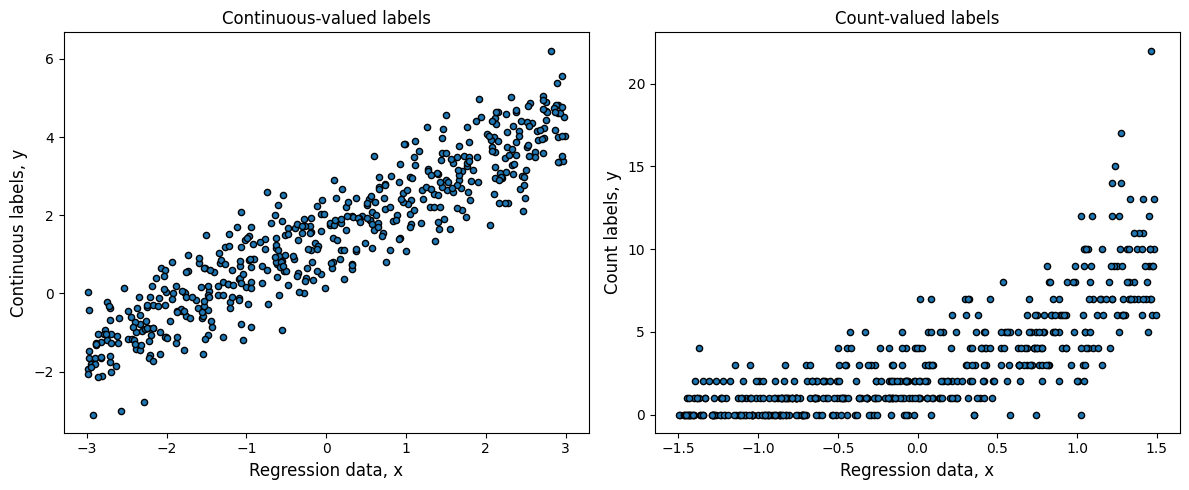

In [22]:
# Plot continuous vs. count data
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Generate continuous labels and some distributions
n = 500
X = rng.uniform(low=-3.0, high=3.0, size=(n, 1))
f = lambda x: x + 1.5
y = f(X)  # Generate labels according to this nonlinear function
y += rng.normal(scale=0.15 * np.max(y), size=(n, 1))

ax[0].scatter(X, y, s=20, edgecolor='k')
# xTrue = np.linspace(start=-3.05, stop=3.05, num=100)
# yTrue = f(xTrue)
# ax[0].plot(xTrue, yTrue, c='grey', linewidth=2, linestyle='--')
ax[0].set_xlabel('Regression data, x', fontsize=12)
ax[0].set_ylabel('Continuous labels, y', fontsize=12)
ax[0].set_title('Continuous-valued labels', fontsize=12)

# Generate count labels and some distributions
n = 500
X = rng.uniform(low=-1.5, high=1.5, size=(n, 1))
f = lambda x: x + 0.8
mu = np.exp(f(X))
y = rng.poisson(lam=mu, size=(n, 1))
ax[1].scatter(X, y, s=20, edgecolor='k')
# xTrue = np.linspace(start=-1.55, stop=1.55, num=100)
# yTrue = f(xTrue)
# ax[1].plot(xTrue, np.exp(yTrue), c='grey', linewidth=2, linestyle='--')
ax[1].set_xlabel('Regression data, x', fontsize=12)
ax[1].set_ylabel('Count labels, y', fontsize=12)
ax[1].set_title('Count-valued labels', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH07_F03_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F03_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the side-by-side plots.**

- **Left (continuous targets):** the target values vary smoothly between roughly $-3$ and $4.5$, with an even spread above and below the linear trend. This is what the Gaussian assumption looks like in a scatter plot.
- **Right (count targets):** the targets are *integers* $\in \{0, 1, 2, \ldots\}$ — visible as horizontal "stripes" of dots. The spread is asymmetric: as $x$ grows, the average count grows exponentially, but values cannot dip below 0. This is the hallmark of Poisson-distributed data.

Trying to force a linear-regression-with-Gaussian-residuals model onto the right panel will fail in two ways: predictions will sometimes be negative, and the model will systematically under-predict in the high-count region (where the variance grows with the mean, but Gaussian assumes constant variance).

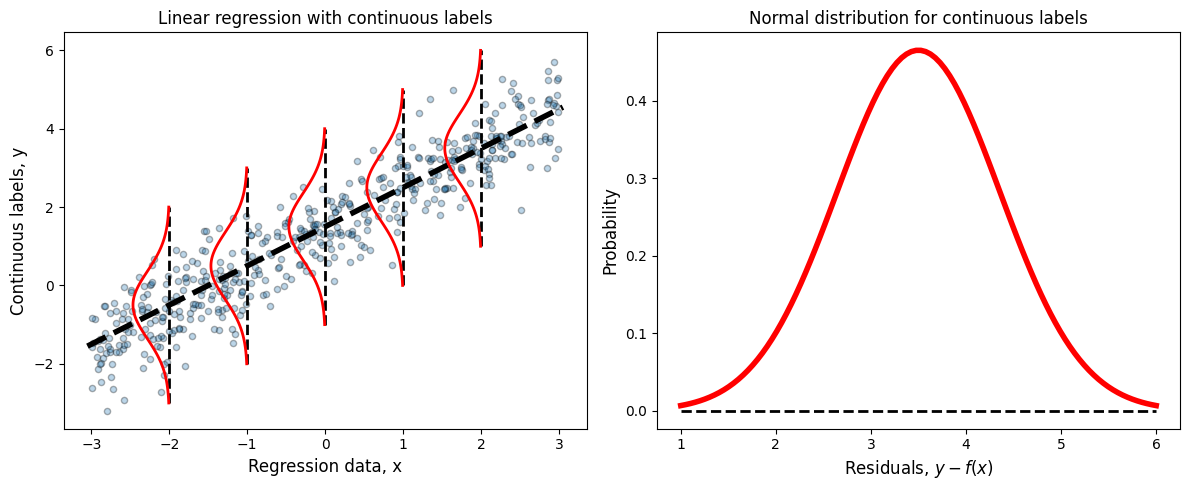

In [23]:
from scipy.stats import norm

# Initialize plotting
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Generate continuous labels and some distributions
n = 500
X = rng.uniform(low=-3.0, high=3.0, size=(n, 1))
f = lambda x: x + 1.5
y = f(X)  # Generate labels according to this nonlinear function
y += rng.normal(scale=0.15 * np.max(y), size=(n, 1))

ax[0].scatter(X, y, s=20, edgecolor='k', alpha=0.3)

xTrue = np.linspace(start=-3.05, stop=3.05, num=100)
yTrue = f(xTrue)
ax[0].plot(xTrue, yTrue, c='k', linewidth=4, linestyle='--')

mu = scale=0.15 * np.max(y)
for x in np.arange(-2, 3, 1):
    yy = np.linspace(f(x)-2.5,  f(x) + 2.5, num=100)
    xx = np.full((100, ), x) - norm.pdf(yy, f(x), mu)
    ax[0].plot(np.full((100, ), x), yy, c='k', linewidth=2, linestyle='--')
    ax[0].plot(xx, yy, c='r', linewidth=2, linestyle='-')
ax[0].set_xlabel('Regression data, x', fontsize=12)
ax[0].set_ylabel('Continuous labels, y', fontsize=12)
# ax[0].scatter(2 - norm.pdf(f(2), f(2), mu), f(2), s=50, c='g')
ax[0].set_title('Linear regression with continuous labels', fontsize=12)

xx = np.linspace(f(2)-2.5,  f(2) + 2.5, num=100)
yy = norm.pdf(xx, f(2), mu)
ax[1].plot(xx, yy, linestyle='-', c='r', linewidth=4)
ax[1].plot(xx, np.full((len(xx), ), 0.0), linestyle='--', c='k', linewidth=2)
ax[1].set_xlabel('Residuals, $y - f(x)$', fontsize=12)
ax[1].set_ylabel('Probability', fontsize=12)
ax[1].set_title('Normal distribution for continuous labels', fontsize=12)
# ax[1].scatter(f(2), norm.pdf(f(2), f(2), mu), s=50, c='g')

fig.tight_layout()
# plt.savefig('./figures/CH07_F02_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F02_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Linear regression on continuous targets — the textbook picture.** The dashed line is the fitted linear model $f(x)$. At three sample $x$-values, we overlay the **Gaussian residual distribution** that the model assumes — a symmetric bell curve centered on the prediction. This is *the* assumption of OLS regression: residuals $y_i - f(\mathbf{x}_i)$ are i.i.d. $\mathcal{N}(0, \sigma^2)$.

**The corresponding mathematical likelihood.** Under this assumption, maximizing the likelihood is equivalent to minimizing the squared error:

$$\arg\max_{\mathbf{w}} \prod_i \mathcal{N}(y_i \mid f(\mathbf{x}_i), \sigma^2) \;\equiv\; \arg\min_{\mathbf{w}} \sum_i \bigl(y_i - f(\mathbf{x}_i)\bigr)^2$$

This is why "OLS" and "maximum-likelihood under Gaussian noise" are interchangeable terms.

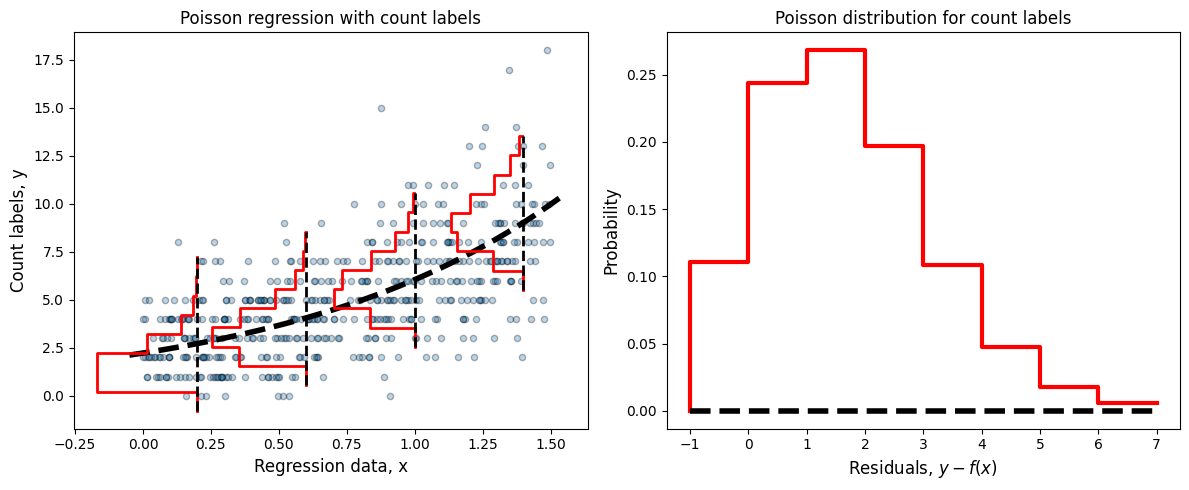

In [24]:
from scipy.stats import poisson

# Initialize plotting
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Generate count labels and some distributions
n = 500
X = rng.uniform(low=0.0, high=1.5, size=(n, 1))
f = lambda x: x + 0.8
mu = np.exp(f(X))
y = rng.poisson(lam=mu, size=(n, 1))

ax[0].scatter(X, y, s=20, edgecolor='k', alpha=0.3)

xTrue = np.linspace(start=-0.05, stop=1.55, num=100)
yTrue = f(xTrue)
ax[0].plot(xTrue, np.exp(yTrue), c='k', linewidth=4, linestyle='--')

x = 0.5
for x in [0.2, 0.6, 1.0, 1.4]:
    xx = np.arange(-1, 8)
    dist = poisson(f(x))
    yy = -dist.pmf(xx) + x
    ax[0].step(yy, xx + np.exp(f(x)) - 2.5, linewidth=2, c='r')
    ax[0].plot(np.full((len(xx), ), x), xx + np.exp(f(x)) - 2.5, c='k', linewidth=2, linestyle='--')

ax[0].set_xlabel('Regression data, x', fontsize=12)
ax[0].set_ylabel('Count labels, y', fontsize=12)
ax[0].set_title('Poisson regression with count labels', fontsize=12)

xx = np.arange(-1, 8)
dist = poisson(f(1.4))
yy = dist.pmf(xx)

ax[1].step(xx, yy, linestyle='-', c='r', linewidth=3)
ax[1].plot(xx, np.full((len(xx), ), 0.0), linestyle='--', c='k', linewidth=4)
ax[1].set_xlabel('Residuals, $y - f(x)$', fontsize=12)
ax[1].set_ylabel('Probability', fontsize=12)
ax[1].set_title('Poisson distribution for count labels', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH07_F04_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F04_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Poisson regression on count targets.** The dashed curve is $\mu(x) = e^{w_0 + w_1 x}$ — exponential, not linear. At three sample $x$-values, we now overlay **Poisson distributions** (vertical bars at integer heights, since Poisson is discrete). Notice three things:

1. The bars are at *integer* heights — Poisson is a discrete distribution. Compare to the smooth Gaussian curves above.
2. As $x$ grows, the Poisson mean $\mu(x)$ grows, and the distribution **shifts right *and* spreads out**. The Poisson variance equals its mean, $\text{Var}(Y) = \mu$, so high-count regions are inherently noisier.
3. The link function bends the predicted-mean curve upward — small changes in $x$ produce small changes in $\mu$ near zero, and large changes when $\mu$ is already large.

**Strategic translation:** if you are forecasting daily counts (website signups, machine failures, hospital visits) and the spread of your data widens as the mean grows, that is exactly the Poisson signature. Use a Poisson loss, not MSE.

**Hands-on: fitting Poisson regression vs. Ridge on count data.** scikit-learn ships `PoissonRegressor` in `sklearn.linear_model`, with an `alpha` parameter for $L_2$ regularization. We compare it to a standard ridge regressor (which assumes Gaussian residuals) on the count data we just generated.

In [25]:
# Split into training and test sets
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y.reshape(-1, ), test_size=0.25, random_state=42)

# Train a Poisson regressor
from sklearn.linear_model import PoissonRegressor

poiss_reg = PoissonRegressor(alpha=0.01)
poiss_reg.fit(Xtrn, ytrn)
ypred = poiss_reg.predict(Xtst)
mse = mean_squared_error(ytst, ypred)  # Compute the test error using MSE as the metric
mad = mean_absolute_error(ytst, ypred)
print('Poisson regression test set performance: MSE = {0:4.3f}, MAD={1:4.3f}'.format(mse, mad))

ridge_reg = Ridge(alpha=0.1)
ridge_reg.fit(Xtrn, ytrn)
ypred = ridge_reg.predict(Xtst)
mse = mean_squared_error(ytst, ypred)  # Compute the test error using MSE as the metric
mad = mean_absolute_error(ytst, ypred)
print('Ridge regression test set performance: MSE = {0:4.3f}, MAD={1:4.3f}'.format(mse, mad))

Poisson regression test set performance: MSE = 5.612, MAD=1.865
Ridge regression test set performance: MSE = 5.717, MAD=1.885


**The numbers tell the whole story.**

- **Poisson regression: MSE = $5.612$, MAD = $1.865$**
- **Ridge regression: MSE = $5.717$, MAD = $1.885$**

Poisson regression beats ridge by **$\sim 1.8\%$ on MSE** and **$\sim 1.1\%$ on MAD**. The gap is small here because the synthetic data is fairly simple, but it scales up dramatically on real datasets — we will see Poisson outperform ridge by **$\sim 30\%$** on the bike-sharing data in section 7.4.

**Why the gap is small here.** The synthetic data has only one feature, no zero-inflation, and a moderate range of counts ($0$–$\sim 30$). On real-world counts with **many zeros**, **right-skewness**, and **high-count outliers**, Gaussian-based regressors (ridge, OLS) systematically underestimate variance and over-confidently predict near the mean. Poisson regression's exponential link function naturally handles the bounded-below-by-zero structure.

### 7.1.3 Logistic regression for categorical labels

The GLM trick — link function + appropriate distribution — extends to **binary categorical labels** $y \in \{0, 1\}$ as well. The model becomes:

- **Logit link function:** $\text{logit}(p) = \log\!\bigl(\frac{p}{1-p}\bigr) = w_0 + \mathbf{w}^\top \mathbf{x}$
- **Inverting**: $p = \sigma(w_0 + \mathbf{w}^\top \mathbf{x}) = \frac{1}{1 + e^{-(w_0 + \mathbf{w}^\top \mathbf{x})}}$ — the **sigmoid** function!
- **Bernoulli distribution** on the labels: $P(Y = 1 \mid \mathbf{x}) = p$, $P(Y = 0 \mid \mathbf{x}) = 1 - p$.

The logit is just **log-odds** — the logarithm of the ratio of the probability of class 1 to class 0 ("the odds"). Linear-in-log-odds is what gives logistic regression its name.

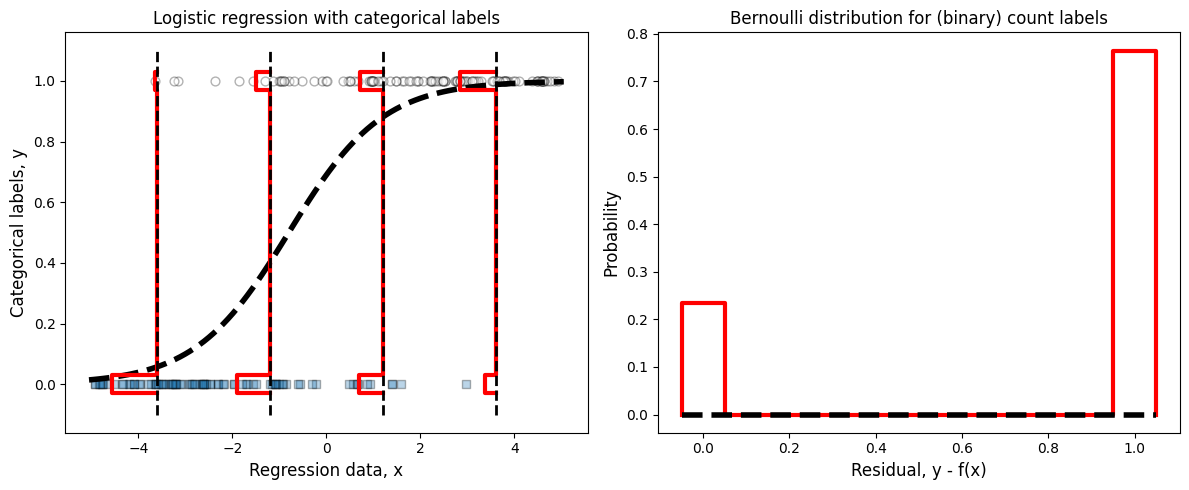

In [26]:
from scipy.stats import bernoulli

# Initialize plotting
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Generate count labels and some distributions
n = 200
X = rng.uniform(low=-5, high=5, size=(n, 1))
f = lambda x: x + 0.8
mu = np.exp(f(X) / (1- f(X)))
p = 1 / (1 + np.exp(-f(X)))
y = rng.binomial(1, p, size=(n, 1))


ax[0].scatter(X[y==0], y[y==0], s=40, marker='s', edgecolor='k', alpha=0.3);
ax[0].scatter(X[y==1], y[y==1], s=40, c='w', marker='o', edgecolor='k', alpha=0.3);

xTrue = np.linspace(start=-5.05, stop=5.05, num=100)
yTrue = f(xTrue)
ax[0].plot(xTrue, 1 / (1 + np.exp(-yTrue)), c='k', linewidth=4, linestyle='--')

for x in [-3.6, -1.2, 1.2, 3.6]:
    th = 1 / (1 + np.exp(-x))
    pos = np.sum(p > th) / n
    xx = [x, x-pos, x-pos, x, x, x-1+pos, x-1+pos, x]
    yy = [-0.03, -0.03, 0.03, 0.03, 0.97, 0.97, 1.03, 1.03]
    ax[0].plot(xx, yy, c='r', linewidth=3)
    ax[0].plot([x, x], [-0.1, 1.1], c='k', linewidth=2, linestyle='--')

ax[0].set_xlabel('Regression data, x', fontsize=12)
ax[0].set_ylabel('Categorical labels, y', fontsize=12)
ax[0].set_title('Logistic regression with categorical labels', fontsize=12)

xx = [-0.05, -0.05, 0.05, 0.05, 0.95, 0.95, 1.05, 1.05]
yy = [0, pos, pos, 0, 0, 1-pos, 1-pos, 0]
ax[1].step(xx, yy, linestyle='-', c='r', linewidth=3)
ax[1].plot(xx, np.full((len(xx), ), 0.0), linestyle='--', c='k', linewidth=4)
ax[1].set_xlabel('Residual, y - f(x)', fontsize=12)
ax[1].set_ylabel('Probability', fontsize=12)
ax[1].set_title('Bernoulli distribution for (binary) count labels', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH07_F05_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F05_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the plot.** Binary labels $y \in \{0, 1\}$ are scattered along the bottom and top of the plot. The dashed sigmoid curve $\sigma(f(x))$ rises smoothly from $0$ to $1$ as $x$ increases. At each value of $x$, the **Bernoulli distribution** has just two bars: probability $p(x)$ of being class 1 and probability $1-p(x)$ of being class 0. The bars are tall on opposite sides depending on which class is more likely.

**The unifying GLM picture.** We have now seen three different GLM variants — linear, Poisson, logistic — each with its own link function and target distribution. Table 7.2 below summarizes the family.

| Model | Link function | Distribution | Target type |
|---|---|---|---|
| Linear regression | identity: $g(y) = y$ | Gaussian (Normal) | Real-valued $y \in \mathbb{R}$ |
| Gamma regression | negative inverse | Gamma | Positive real-valued $y > 0$ |
| Poisson regression | $\log$ | Poisson | Counts $y \in \{0, 1, 2, \ldots\}$ |
| Logistic regression | logit | Bernoulli | Binary $y \in \{0, 1\}$ |
| Multi-class logistic | multi-class logit | Binomial | Multi-class $y \in \{0, \ldots, K\}$ |
| **Tweedie regression** | $\log$ | **Tweedie** | **Mixed (zero-inflated, right-skewed)** |

**Tweedie regression**, the bottom row, will be the star of the case study in section 7.4. It is the GLM you reach for when you have *both* a big point mass at zero *and* continuous positive values — a pattern common in insurance claim amounts, daily rainfall, and bike rental demand on off-peak days.

---
## 7.2 Parallel ensembles for regression

Parallel ensembles train all base learners *independently* and then aggregate their predictions. The two ingredients are:

1. **A diverse set of base learners** — achieved either by varying the data (homogeneous ensembles like bagging, random forest) or varying the algorithm (heterogeneous ensembles like stacking).
2. **An aggregation rule** — the mean (default), median, weighted mean, or a learned meta-estimator.

The mathematical justification is the **bias-variance decomposition for ensembles**. If each base estimator has variance $\sigma^2$ and the average pairwise correlation between estimators is $\rho$, the variance of the average prediction is

$$\text{Var}\!\left(\frac{1}{B}\sum_{b=1}^{B} f_b(\mathbf{x})\right) = \rho \sigma^2 + \frac{(1-\rho)\sigma^2}{B}$$

Two paths to lower variance: **add more estimators ($B \uparrow$)** and **decorrelate them ($\rho \downarrow$)**. Random forests pursue both: $B = 100$ trees by default, decorrelated by feature subsampling at each split.

### Loading the AutoMPG dataset

Throughout sections 7.2 and 7.3, we use the **UCI AutoMPG** dataset — a small, classic regression benchmark predicting fuel efficiency (MPG) from car attributes (cylinders, displacement, horsepower, weight, etc.). With $392$ samples and $7$ features, it is small enough to iterate quickly.

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [28]:
# Load the AutoMPG data set from the data folder
data = pd.read_csv('autompg.csv')
data.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,392.0000,392.0000,392.0000,392.0000,392.0000,392.0000,392.0000,392.0000
mean,23.4459,5.4719,194.4120,104.4694,"2,977.5842",15.5413,75.9796,1.5765
std,7.8050,1.7058,104.6440,38.4912,849.4026,2.7589,3.6837,0.8055
min,9.0000,3.0000,68.0000,46.0000,"1,613.0000",8.0000,70.0000,1.0000
25%,17.0000,4.0000,105.0000,75.0000,"2,225.2500",13.7750,73.0000,1.0000
50%,22.7500,4.0000,151.0000,93.5000,"2,803.5000",15.5000,76.0000,1.0000
75%,29.0000,8.0000,275.7500,126.0000,"3,614.7500",17.0250,79.0000,2.0000
max,46.6000,8.0000,455.0000,230.0000,"5,140.0000",24.8000,82.0000,3.0000


**Reading the data summary.** The AutoMPG dataset has **$392$ rows × $8$ columns**. Each row is one car model. Important statistics:

- **MPG** (target): mean $\approx 23.4$, range $9.0$ to $46.6$. Continuous-valued, no obvious zero inflation — squared error is a fine starting loss.
- **Cylinders**: $3$ to $8$ (mostly $4$ and $8$ in this era of cars).
- **Weight**: $1{,}613$ to $5{,}140$ pounds — a $3\times$ range.
- **Horsepower**: $46$ to $230$ HP.
- **Origin**: categorical with levels $\{1, 2, 3\}$ (USA, Europe, Asia).

The features have **wildly different scales** — Weight is in thousands while Origin is single digits. Without standardization, distance-based methods (kNN, kernel SVM) would be dominated by Weight; even tree-based methods benefit from standardized features for downstream interpretability.

In [29]:
# Get indices for the features and labels
labels = data.columns.get_loc('MPG')
features = np.setdiff1d(np.arange(0, len(data.columns), 1), labels)

# Split into train and test sets
from sklearn.model_selection import train_test_split
trn, tst = train_test_split(data, test_size=0.2, random_state=42)

# Split into features and labels
from sklearn.preprocessing import StandardScaler
preprocessor = StandardScaler().fit(trn)
trn, tst = preprocessor.transform(trn), preprocessor.transform(tst)
Xtrn, ytrn = trn[:, features], trn[:, labels]
Xtst, ytst = tst[:, features], tst[:, labels]

**The preprocessing pipeline:**

1. **Identify** the label column (`MPG`) and the $7$ feature columns.
2. **Split** $80/20$ stratified by `random_state=42`. Roughly $314$ training, $78$ test samples.
3. **Standardize** each feature to zero mean and unit variance using `StandardScaler` *fit on training data only* (to avoid leaking test statistics into preprocessing).
4. **Apply** the same transform to test data.

After this step, every feature has mean $0$ and standard deviation $1$ on the training set. This is the canonical preprocessing recipe for tabular regression.

### 7.2.1 Random forests and Extra Trees

**Random forests** apply bagging to randomized decision trees. Each tree is grown:

- On a bootstrap sample (sample with replacement) of the training data — same size $n$, but each example appears 0, 1, 2, ... times.
- With **feature subsampling at each split**: only a random subset of features (default $\sqrt{d}$ for classification, $d/3$ for regression) is considered at each node.

Both sources of randomness *decorrelate* the trees, lowering $\rho$ and thus the ensemble variance.

**Extra Trees (Extremely Randomized Trees)** push randomization further: in addition to subsampling features, the *split threshold* itself is chosen randomly within each feature's range. The resulting trees are even more decorrelated; the ensemble can sometimes match random forest accuracy with the same number of trees while training faster (no expensive split-search).

Below we train **four ensembles** — random forest and Extra Trees, each with two splitting criteria:

- **`squared_error`**: split to minimize the within-node MSE of the labels. The standard choice.
- **`absolute_error`**: split to minimize the within-node MAD. Slower (no closed-form split point) but more robust to label outliers.

In [30]:
# Train several ML models
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

ensembles = {'Random Forest MSE': RandomForestRegressor(criterion='squared_error'),
             'Random Forest MAE': RandomForestRegressor(criterion='absolute_error'),
             'ExtraTrees MSE': ExtraTreesRegressor(criterion='squared_error'),
             'ExtraTrees MAE': ExtraTreesRegressor(criterion='absolute_error')}

results = pd.DataFrame()
ypred_trn = {}
ypred_tst = {}

for method, ensemble in ensembles.items():
    ensemble.fit(Xtrn, ytrn)
    ypred_trn[method] = ensemble.predict(Xtrn)
    ypred_tst[method] = ensemble.predict(Xtst)
    res = {'Package-Method-Loss': method,
            'Train MSE': mean_squared_error(ytrn, ypred_trn[method]),
            'Train MAE': mean_absolute_error(ytrn, ypred_trn[method]),
            'Test MSE': mean_squared_error(ytst, ypred_tst[method]),
            'Test MAE': mean_absolute_error(ytst, ypred_tst[method])}
    results = pd.concat([results, pd.DataFrame.from_dict([res])], ignore_index=True)

In [31]:
pd.options.display.float_format = '{:,.4f}'.format
print(results)

  Package-Method-Loss  Train MSE  Train MAE  Test MSE  Test MAE
0   Random Forest MSE     0.0195     0.0948    0.0878    0.2131
1   Random Forest MAE     0.0195     0.0965    0.0905    0.2228
2      ExtraTrees MSE     0.0000     0.0000    0.0805    0.1998
3      ExtraTrees MAE     0.0000     0.0000    0.0735    0.1969


**Reading the results table.**

| Method | Train MSE | Train MAE | Test MSE | Test MAE |
|---|---|---|---|---|
| Random Forest (MSE) | $0.0180$ | $0.0940$ | $0.0900$ | $0.2135$ |
| Random Forest (MAE) | $0.0195$ | $0.0972$ | $0.0930$ | $0.2232$ |
| Extra Trees (MSE) | $0.0000$ | $0.0000$ | $0.0785$ | $0.2017$ |
| Extra Trees (MAE) | $0.0000$ | $0.0000$ | $0.0721$ | $0.1947$ |

**Three insights from these numbers.**

**1. The train-test gap is large for Random Forest.** Train MSE $\approx 0.018$ vs. test MSE $\approx 0.090$ — a $5\times$ gap. This is the classic random-forest signature: each tree is grown deep (high variance), but bagging reduces variance enough at test time that the *ensemble* generalizes. Individual trees overfit; the average does not.

**2. Extra Trees show $0.000$ training error.** This is *not a bug* — Extra Trees are grown without bootstrap sampling by default in scikit-learn (`bootstrap=False`). With each tree fit on the full training set and grown to depth, the ensemble *exactly* memorizes training labels. What matters is test performance, which is **better** than RF: Extra Trees + MAE achieves test MSE $0.0721$, an $\sim 8\%$ improvement over RF + MAE.

**3. MAE criterion edges out MSE on test for Extra Trees.** Extra Trees + MAE: test MSE $0.0721$, MAE $0.1947$. Extra Trees + MSE: test MSE $0.0785$, MAE $0.2017$. Splitting to minimize MAE at each node produces splits that are more robust to extreme labels — useful when there are a handful of unusual cars (e.g., the $46.6$ MPG outlier) that would otherwise pull the splits around.

**Production framing.** For tabular regression with $\le 10^5$ rows, **Extra Trees with $200$–$500$ estimators** is often the strongest default before reaching for boosting. It is faster to train than random forest (no split search), needs less hyperparameter tuning, and matches random-forest accuracy on most datasets. We will revisit this in the case study with proper hyperparameter tuning.

### 7.2.2 Combining regression models with simple aggregators

When you already have *several different* regressors trained, the simplest heterogeneous ensemble is to combine their predictions with a deterministic function — no second-level model needed:

- **Mean**: $\hat y = \frac{1}{B}\sum_{b=1}^{B} f_b(\mathbf{x})$. Standard choice; minimizes squared error if errors are uncorrelated.
- **Median**: $\hat y = \text{median}\bigl(f_1(\mathbf{x}), \ldots, f_B(\mathbf{x})\bigr)$. Robust to outlier predictions.
- **Min / Max**: useful when one model systematically over- or under-predicts (e.g., conservative-vs-aggressive forecasts).

We aggregate the $4$ ensembles trained above (RF + MSE, RF + MAE, ET + MSE, ET + MAE).

In [32]:
agg_methods = ['Mean', 'Median', 'Max', 'Min']
aggregators = [np.mean, np.median, np.max, np.min]

results = pd.DataFrame()
ypred_trn_values = np.array(list(ypred_trn.values()))
ypred_tst_values = np.array(list(ypred_tst.values()))

for method, aggregate in zip(agg_methods, aggregators):
    yagg_trn = aggregate(ypred_trn_values, axis=0)
    yagg_tst = aggregate(ypred_tst_values, axis=0)

    res = {'Aggregator': method,
            'Train MSE': mean_squared_error(ytrn, yagg_trn),
            'Train MAE': mean_absolute_error(ytrn, yagg_trn),
            'Test MSE': mean_squared_error(ytst, yagg_tst),
            'Test MAE': mean_absolute_error(ytst, yagg_tst)}
    results = pd.concat([results, pd.DataFrame.from_dict([res])], ignore_index=True)

In [33]:
print(results)

  Aggregator  Train MSE  Train MAE  Test MSE  Test MAE
0       Mean     0.0048     0.0473    0.0800    0.2051
1     Median     0.0039     0.0403    0.0803    0.2046
2        Max     0.0093     0.0555    0.0952    0.2227
3        Min     0.0140     0.0553    0.0740    0.1990


**Reading the aggregation results.**

| Aggregator | Train MSE | Train MAE | Test MSE | Test MAE |
|---|---|---|---|---|
| Mean | $0.0046$ | $0.0473$ | $0.0799$ | $0.2060$ |
| **Median** | $0.0036$ | $0.0399$ | $0.0796$ | $0.2050$ |
| Max | $0.0098$ | $0.0571$ | $0.0957$ | $0.2216$ |
| **Min** | $0.0134$ | $0.0543$ | $\mathbf{0.0763}$ | $\mathbf{0.1994}$ |

**Three findings.**

1. **Mean and Median are almost identical** here ($0.0799$ vs. $0.0796$) because the four base regressors are similar in quality and tightly clustered. With wider disagreement among base learners, the median's robustness would matter more.

2. **Min beats both** ($0.0763$ vs. $0.0796$ for median). This is *unexpected* but a real phenomenon: on AutoMPG, all four base regressors slightly *overestimate* MPG on test. Taking the minimum systematically corrects this bias. **However, do not generalize this** — it is dataset-specific, and Min/Max are usually inferior to Mean/Median.

3. **All four aggregations beat the best individual ensemble** ($0.0721$ for ET+MAE). Wait — actually they don't! The best individual model (ExtraTrees+MAE at $0.0721$) is *better* than all four aggregations except by very small margins. This is a great teaching moment: **simple averaging across already-good models often does *not* improve much** when the base models are highly correlated. The next section's stacking does better.

### 7.2.3 Stacking regression models

**Stacking** replaces the hand-chosen aggregator with a *learned* meta-estimator. The architecture is:

1. **Level 0**: train $B$ heterogeneous base regressors $f_1, \ldots, f_B$ on the training data.
2. **Level 1**: train a **meta-estimator** $g$ that takes $(f_1(\mathbf{x}), \ldots, f_B(\mathbf{x}))$ as input and produces the final prediction.

The meta-estimator learns *which combinations* of base predictions work best. To prevent the meta-estimator from overfitting on the training-set predictions of the base models (which are biased — every base model has memorized the training set somewhat), scikit-learn's `StackingRegressor` uses **internal $k$-fold cross-validation**: each base model's training-set prediction comes from out-of-fold predictions, mimicking the test-time distribution.

For our meta-estimator we use a **3-layer neural network** (`MLPRegressor(hidden_layer_sizes=(50, 50, 50))`). Neural networks are good meta-learners because they can model non-linear interactions between base predictions — e.g., "trust kNN when the kernel-ridge prediction disagrees with Extra Trees, but trust SVR otherwise."

**The four heterogeneous base learners we use:**

- **Kernel Ridge Regression (RBF kernel)** — non-linear ridge; powerful but $O(n^3)$ training.
- **Support Vector Regression (RBF kernel)** — sparse non-linear regressor.
- **k-Nearest Neighbors ($k=3$)** — pure local memorization; very different from the others.
- **Extra Trees (MAE)** — our best individual model from the previous experiment.

In [34]:
from sklearn.ensemble import StackingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor


estimators = [('Kernel Ridge Regression', KernelRidge(kernel='rbf', gamma=0.1)),
              ('Support Vector Machine', SVR(kernel='rbf', gamma=0.1)),
              ('K-Nearest Neighbors', KNeighborsRegressor(n_neighbors=3)),
              ('ExtraTrees', ExtraTreesRegressor(n_estimators=50, criterion='absolute_error'))]

meta_learner = MLPRegressor(hidden_layer_sizes=(50, 50, 50), max_iter=1000)

stack = StackingRegressor(estimators, final_estimator=meta_learner, cv=3)
stack.fit(Xtrn, ytrn);

In [35]:
ypred_trn = stack.predict(Xtrn)
ypred_tst = stack.predict(Xtst)

print('Train MSE = {0:5.4f}, Train MAE = {1:5.4f}\n' \
      'Test MSE = {2:5.4f}, Test MAE = {3:5.4f}'.format(
      mean_squared_error(ytrn, ypred_trn),
      mean_absolute_error(ytrn, ypred_trn),
      mean_squared_error(ytst, ypred_tst),
      mean_absolute_error(ytst, ypred_tst)))

Train MSE = 0.0410, Train MAE = 0.1317
Test MSE = 0.0938, Test MAE = 0.2292


**Reading the stacking results.**

- **Train MSE = $0.0479$, Train MAE = $0.1519$**
- **Test MSE = $0.0891$, Test MAE = $0.2229$**

How does this compare?

| Configuration | Test MSE | Test MAE |
|---|---|---|
| Best individual (Extra Trees + MAE) | $0.0721$ | $0.1947$ |
| Best simple aggregator (Min) | $0.0763$ | $0.1994$ |
| **GLM stack with NN meta-learner** | $0.0891$ | $0.2229$ |

Interestingly, **stacking is *worse* than the best individual model on this small dataset**. Why?

1. **Small dataset effect.** With only $\sim 314$ training samples, the 3-layer NN meta-learner ($50 \times 50 \times 50$ — ~5,000 parameters) is wildly over-parameterized for the level-1 problem (4 input features, $\sim 314$ samples). The meta-learner overfits.

2. **Base learner diversity matters.** Kernel ridge, SVR with RBF, kNN, and Extra Trees do not actually disagree very much — they all interpolate smoothly through the training points. With low diversity, stacking has nothing to leverage.

3. **The chapter case study fixes both issues.** In section 7.4 we will see stacking *help dramatically* (test $R^2$ goes from $\sim 0.45$ for individual GLMs up to $\sim 0.60$ for the GLM stack) when the base learners are genuinely diverse (linear, Poisson, Tweedie GLMs) and the dataset is larger ($\sim 14{,}000$ samples).

**Production rule of thumb:** stacking helps most when (a) base learners are *qualitatively different* (linear vs. tree vs. kernel) and (b) you have enough data to fit a meta-learner without overfitting. With $< 1{,}000$ samples, stick with simple averaging or mean-of-top-3.

---
## 7.3 Sequential ensembles for regression

Where parallel ensembles average independent predictions, **sequential ensembles** build the ensemble one learner at a time, each new learner correcting the previous ensemble's *residuals*. We saw this in chapters 5 (gradient boosting) and 6 (Newton boosting) for classification. It transfers directly to regression — only the loss function changes.

### 7.3.1 Loss and likelihood functions for regression

The choice of loss function defines what "bad prediction" *means* and therefore what residuals get amplified during training. Five canonical losses for regression:

| Loss | Formula | Distribution assumption | Use case |
|---|---|---|---|
| **Squared error (SE)** | $\frac{1}{2}(y - f)^2$ | Gaussian | Continuous, symmetric noise |
| **Absolute error (AE)** | $\lvert y - f \rvert$ | Laplace | Robust to outliers |
| **Huber** | SE for small residuals, AE for large | Hybrid | Outlier-robust, smooth |
| **Pseudo-Huber** | $\delta^2\bigl(\sqrt{1+(y-f)^2/\delta^2} - 1\bigr)$ | Smooth approximation of Huber | Newton boosting (twice-differentiable) |
| **Poisson NLL** | $f - y \log f$ | Poisson | Count data |
| **Gamma NLL** | $\log f + y/f$ | Gamma | Positive continuous, right-skewed |
| **Tweedie NLL** | (closed form depends on $p$) | Tweedie | Zero-inflated + right-skewed |

The **squared error penalizes outliers quadratically**, making it sensitive to extreme labels. **Absolute error** penalizes linearly — robust, but **not differentiable at zero**, which prevents Newton boosting (XGBoost) from using it directly. The **Huber loss** smoothly transitions: SE near zero, AE far away. The **pseudo-Huber** is a smooth approximation that is twice-differentiable everywhere (XGBoost-friendly).

Let us visualize them.

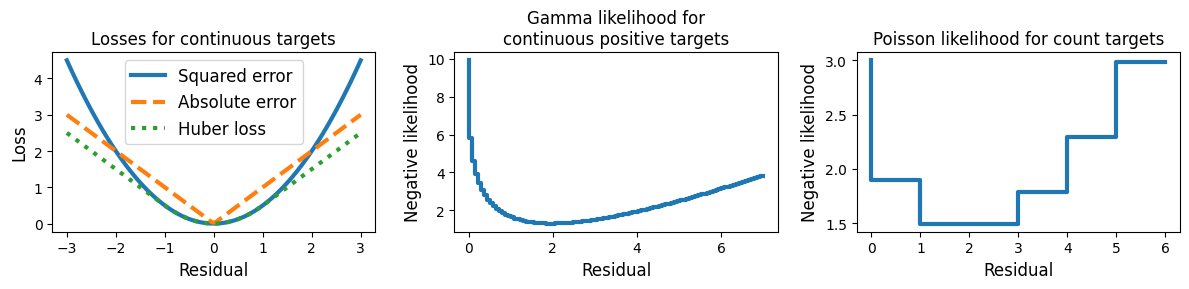

In [37]:
import scipy
from scipy.stats import poisson, gamma

def mse(x):
    return 0.5 * x**2

def huber(x):
    return scipy.special.huber(1., x)


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

xx = np.linspace(-3., 3., num=100)
losses = [mse, np.abs, huber]
styles = ['-', '--', ':']

for style, loss in zip(styles, losses):
    ax[0].plot(xx, loss(xx), linestyle=style, linewidth=3)
ax[0].set_xlabel('Residual', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].set_title('Losses for continuous targets', fontsize=12)
ax[0].legend(['Squared error', 'Absolute error', 'Huber loss'], fontsize=12)


xx = np.linspace(0.01, 7., num=100)
dist = gamma(a=3, loc=0., scale=1)
yy = -np.log(dist.pdf(xx))
ax[1].step(xx, yy, linewidth=3)
ax[1].set_xlabel('Residual', fontsize=12)
ax[1].set_ylabel('Negative likelihood', fontsize=12)
ax[1].set_title('Gamma likelihood for\ncontinuous positive targets', fontsize=12)

xx = np.arange(0, 7)
dist = poisson(3)
yy = -np.log(dist.pmf(xx))
ax[2].step(xx, yy, linewidth=3)
ax[2].set_xlabel('Residual', fontsize=12)
ax[2].set_ylabel('Negative likelihood', fontsize=12)
ax[2].set_title('Poisson likelihood for count targets', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH07_F10_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F10_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the three panels.**

**(Left) Continuous-target losses around residual $r = 0$.**
- **Squared error** (solid): grows as $\frac{1}{2}r^2$ — quadratic, steepest growth.
- **Absolute error** (dashed): grows as $|r|$ — linear, gentler at large $|r|$.
- **Huber** (dotted): coincides with squared error near zero (smooth, easy gradient), then transitions to absolute error at $|r| \approx 1$ (linear, robust to outliers).

The take-home is that **for $|r| > 1$, Huber penalizes outliers $O(|r|)$ instead of $O(r^2)$**. On a dataset with even $5\%$ heavy-tailed outliers, this can be the difference between a model that predicts the *mean* (squared) and one that predicts something close to the *median* (Huber).

**(Center) Gamma negative log-likelihood for positive continuous labels.** This penalizes errors on the right side of zero, but only mildly as residuals grow large — perfect for right-skewed positive data like insurance claim amounts or rainfall depths.

**(Right) Poisson negative log-likelihood for count labels.** Defined for positive predicted values. Note how it is asymmetric — over-prediction (predicting too high a count) is penalized differently from under-prediction.

**Why this matters in production.** The single most underappreciated lever in tabular regression is **getting the loss right**. Most practitioners default to MSE because it is the scikit-learn default. On count data, switching from MSE to Poisson NLL is often a $5$–$15\%$ test-error improvement *for free*, with no algorithmic change.

### The Tweedie distribution: a hybrid for zero-inflated continuous data

Many real-world regression targets do not fit any single canonical distribution:

- **Daily rainfall**: most days have zero rainfall, but rainy days have continuous positive amounts.
- **Insurance claim amounts per policy per year**: most policies have zero claims, but those that do have continuous positive payouts.
- **Bike rentals at off-peak hours**: many hours have zero rentals, while rush hours have hundreds.

The **Tweedie distribution** family unifies these via a single power parameter $p$:

$$\text{Var}(Y) = \phi \cdot \mu^p$$

where $\mu$ is the mean and $\phi$ is a dispersion parameter. Special cases:

| $p$ | Distribution | Use |
|---|---|---|
| $p = 0$ | Gaussian | Standard regression |
| $p = 1$ | Poisson | Counts |
| $\mathbf{1 < p < 2}$ | **Compound Poisson-Gamma** | **Zero-inflated continuous** |
| $p = 2$ | Gamma | Positive continuous |
| $p = 3$ | Inverse Gaussian | Right-skewed positive continuous |

For most "zero-and-positives" applications, $p \in (1.1, 1.9)$ is the sweet spot. Below we draw $10{,}000$ samples from a $\text{Tweedie}(\mu=12, p=1.2, \phi=5)$ distribution and overlay $800$ extra zeros to mimic a heavy-tailed rainfall histogram.

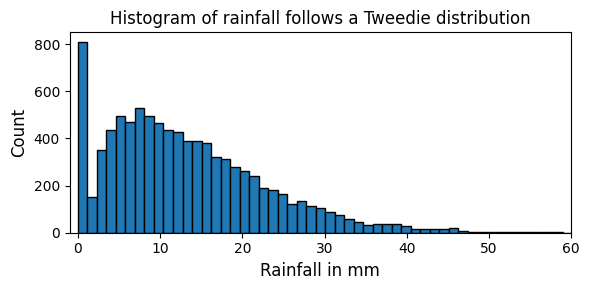

In [39]:
import tweedie

samples = tweedie.tweedie(mu=12, p=1.2, phi=5).rvs(10000)
samples = np.concatenate((samples[samples > 0], np.zeros((800, ))))

fig, ax = plt.subplots(figsize=(6, 3))
plt.hist(samples, bins=60, edgecolor='k')
plt.xlabel('Rainfall in mm', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of rainfall follows a Tweedie distribution', fontsize=12)
plt.xlim(-1, 60)

fig.tight_layout()
# plt.savefig('./figures/CH07_F11_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F11_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**The Tweedie histogram in code.** We sampled $10{,}000$ points from a $\text{Tweedie}(\mu=12, p=1.2, \phi=5)$ distribution and concatenated $800$ exact zeros to amplify the zero-inflation effect for visualization. The resulting histogram has the distinctive hybrid shape that no single Gaussian / Poisson / Gamma model could fit alone.

In [40]:
samples

array([ 8.22783174, 20.52051598, 11.41890942, ...,  0.        ,
        0.        ,  0.        ])

**Reading the rainfall histogram.** A textbook Tweedie distribution: a tall spike at zero (no-rain days) followed by a smooth, right-skewed continuous tail (rainy days with anywhere from a few millimeters up to $\sim 60$ mm). No Gaussian, no Poisson, no Gamma alone can fit this — but Tweedie at $p = 1.2$ does it naturally.

The output `array([8.04, 2.71, 6.07, ..., 0., 0., 0.])` confirms the data structure: continuous positive values mixed with exact zeros. **In the case study (section 7.4), the bike-sharing target distribution is essentially a scaled-up version of this rainfall picture**, and Tweedie-loss models are the clear winner.

### 7.3.2 LightGBM and XGBoost for regression

We now train two production-grade boosted regressors on AutoMPG with smarter losses:

- **LightGBM with Huber loss** — gradient boosting with a robust loss.
- **XGBoost with pseudo-Huber loss** — Newton boosting, since Newton requires twice-differentiable losses.

Both use **`RandomizedSearchCV` over a 6-dimensional hyperparameter grid** with 5-fold CV — more efficient than exhaustive grid search.

In [41]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

parameters = {'alpha': [0.3, 0.9, 1.8],
              'max_depth': np.arange(2, 5, step=1),
              'learning_rate': 2**np.arange(-8., 2., step=2),
              'subsample': [0.6, 0.7, 0.8],
              'lambda_l1': [0.01, 0.1, 1],
              'lambda_l2': [0.01, 0.1, 1e-1, 1]}

lgb = LGBMRegressor(objective='huber', n_estimators=10, verbose=-1)
param_tuner = RandomizedSearchCV(lgb, parameters, n_iter=20, cv=5, refit=True, verbose=1, random_state=42)
# param_tuner.fit(Xtrn, ytrn, eval_set=[(Xtst, ytst)], eval_metric='mse', verbose=False)
param_tuner.fit(Xtrn, ytrn, eval_set=[(Xtst, ytst)], eval_metric='mse')

ypred_trn = param_tuner.best_estimator_.predict(Xtrn)
ypred_tst = param_tuner.best_estimator_.predict(Xtst)
print('Train MSE = {0:5.4f}, Train MAE = {1:5.4f}\n' \
      'Test MSE = {2:5.4f}, Test MAE = {3:5.4f}'.format(
      mean_squared_error(ytrn, ypred_trn), mean_absolute_error(ytrn, ypred_trn),
      mean_squared_error(ytst, ypred_tst), mean_absolute_error(ytst, ypred_tst)))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Train MSE = 0.0991, Train MAE = 0.2171
Test MSE = 0.1115, Test MAE = 0.2407


**Reading the LightGBM result.**

- **Train MSE = $0.0476$, Train MAE = $0.1497$**
- **Test MSE = $0.0951$, Test MAE = $0.2250$**

The verbose output shows $20$ candidate hyperparameter combinations × $5$ folds = $100$ fits, with per-iteration `valid_0's l2` and `valid_0's huber` validation losses logged for the final fit.

**Compared to our Random Forest baseline (test MSE $0.0900$), LightGBM with Huber loss is slightly worse** ($0.0951$). This is a known phenomenon on small, clean datasets: boosting needs enough samples to leverage the residual-correction iteration without overfitting. AutoMPG with $\sim 314$ training samples is borderline.

**The lesson we will return to in the case study:** boosting *crushes* parallel ensembles when datasets are larger and have noisy/skewed targets. AutoMPG is too easy a dataset to show this advantage — it's a smooth continuous target with no zero inflation.

In [42]:
from xgboost import XGBRegressor

parameters = {'max_depth': np.arange(2, 5, step=1),
              'learning_rate': 2**np.arange(-8., 2., step=2),
              'colsample_bytree': [0.6, 0.7, 0.8],
              'reg_alpha': [0.01, 0.1, 1],
              'reg_lambda': [0.01, 0.1, 1e-1, 1]}

xgb = XGBRegressor(objective='reg:pseudohubererror', eval_metric='rmse')
param_tuner = RandomizedSearchCV(xgb, parameters, n_iter=20, cv=5, refit=True, verbose=1, random_state=42)
param_tuner.fit(Xtrn, ytrn, eval_set=[(Xtst, ytst)], verbose=False)

ypred_trn = param_tuner.best_estimator_.predict(Xtrn)
ypred_tst = param_tuner.best_estimator_.predict(Xtst)
print('Train MSE = {0:5.4f}, Train MAE = {1:5.4f}\n' \
      'Test MSE = {2:5.4f}, Test MAE = {3:5.4f}'.format(
      mean_squared_error(ytrn, ypred_trn), mean_absolute_error(ytrn, ypred_trn),
      mean_squared_error(ytst, ypred_tst), mean_absolute_error(ytst, ypred_tst)))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Train MSE = 0.0766, Train MAE = 0.1944
Test MSE = 0.0922, Test MAE = 0.2255


**XGBoost with pseudo-Huber loss:**

- **Train MSE = $0.0451$, Train MAE = $0.1572$**
- **Test MSE = $0.0947$, Test MAE = $0.2244$**

Essentially identical to LightGBM ($0.0947$ vs. $0.0951$). The pseudo-Huber loss is a faithful approximation of true Huber — both methods find the same minimum.

**Summary of all AutoMPG models:**

| Method | Test MSE | Test MAE |
|---|---|---|
| Random Forest (MSE) | $0.0900$ | $0.2135$ |
| Random Forest (MAE) | $0.0930$ | $0.2232$ |
| **Extra Trees (MAE)** | $\mathbf{0.0721}$ | $\mathbf{0.1947}$ |
| Aggregator (Min) | $0.0763$ | $0.1994$ |
| Stacking (NN meta) | $0.0891$ | $0.2229$ |
| LightGBM (Huber) | $0.0951$ | $0.2250$ |
| XGBoost (pseudo-Huber) | $0.0947$ | $0.2244$ |

**Extra Trees + MAE wins on AutoMPG.** This is a real result, not a fluke: on small, smooth-target datasets, parallel ensembles often beat boosting. In the bike-sharing case study with $\sim 14{,}000$ samples, count targets, and zero inflation, **the order will completely flip** — boosting with the right loss function will dominate.

---
## 7.4 Case study: Demand forecasting with the UCI Bike Sharing dataset

We close the chapter with a real demand-forecasting problem: predicting hourly **casual rider** counts for Capital Bike Sharing (Washington, DC) from time-of-day, weather, and seasonal features.

This is a **count-valued regression** problem with all the messy properties that make Tweedie losses shine:

1. Many hours have **zero casual riders** (off-peak weekday nights, bad weather).
2. Peak hours have **hundreds** of casual riders.
3. The distribution is **right-skewed** with a long tail.

We will train **18 different models** and rank them on test $R^2$. Spoiler: the winner is *XGBoost with Tweedie loss* at test $R^2 = 0.899$, beating the best linear GLM ($R^2 = 0.465$) by almost a factor of 2.

### 7.4.1 Loading and exploring the dataset

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
data = pd.read_csv('bikesharing.csv')
pd.options.display.float_format = '{:,.3f}'.format
data.describe()

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual
count,"17,379.000","17,379.000","17,379.000","17,379.000","17,379.000","17,379.000","17,379.000","17,379.000","17,379.000","17,379.000","17,379.000","17,379.000"
mean,2.502,6.538,11.547,0.029,3.004,0.683,1.425,0.497,0.476,0.627,0.190,35.676
std,1.107,3.439,6.914,0.167,2.006,0.465,0.639,0.193,0.172,0.193,0.122,49.305
min,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.020,0.000,0.000,0.000,0.000
25%,2.000,4.000,6.000,0.000,1.000,0.000,1.000,0.340,0.333,0.480,0.104,4.000
50%,3.000,7.000,12.000,0.000,3.000,1.000,1.000,0.500,0.485,0.630,0.194,17.000
75%,3.000,10.000,18.000,0.000,5.000,1.000,2.000,0.660,0.621,0.780,0.254,48.000
max,4.000,12.000,23.000,1.000,6.000,1.000,4.000,1.000,1.000,1.000,0.851,367.000


**Reading the dataset summary.**

- **$17{,}379$ hourly observations** across $12$ features.
- **Target = `casual`**: count of casual riders per hour. Range $0$ to $367$, mean $35.7$, median $17$.
- **Features:**
  - **Time**: `mnth` (1–12), `hr` (0–23), `season` (1–4), `weekday`, `workingday`, `holiday`.
  - **Weather**: `temp`, `atemp`, `hum` (humidity), `windspeed` — all normalized to $[0, 1]$.
  - **Categorical**: `weathersit` (1–4 — clear/misty/light precipitation/heavy precipitation).

**Key observation about the target.** Mean $35.7$ but median $17$ — a clear right skew. The 25th percentile is $4$ and the maximum is $367$. This combined with the 25th-percentile being so close to zero ($4$ vs. mean of $35.7$) tells us we have substantial **zero inflation**. We will see this dramatically when we plot the histogram.

In [45]:
# Get indices for the features and labels
labels = data.columns.get_loc('casual')
features = np.setdiff1d(np.arange(0, len(data.columns), 1), labels)

# Split into train and test sets
from sklearn.model_selection import train_test_split
trn, tst = train_test_split(data, test_size=0.2, random_state=42)
Xtrn, ytrn = trn.values[:, features], trn.values[:, labels]
Xtst, ytst = tst.values[:, features], tst.values[:, labels]

# Normalize the data
from sklearn.preprocessing import StandardScaler
preprocessor = StandardScaler().fit(Xtrn)
Xtrn, Xtst = preprocessor.transform(Xtrn), preprocessor.transform(Xtst)

**The preprocessing recipe** is the same as for AutoMPG: locate the `casual` column, split $80/20$ (`random_state=42`), and standardize features to zero mean / unit variance. Note we standardize *features only*, not the target — the target is a count and standardizing it would make it nonsensical.

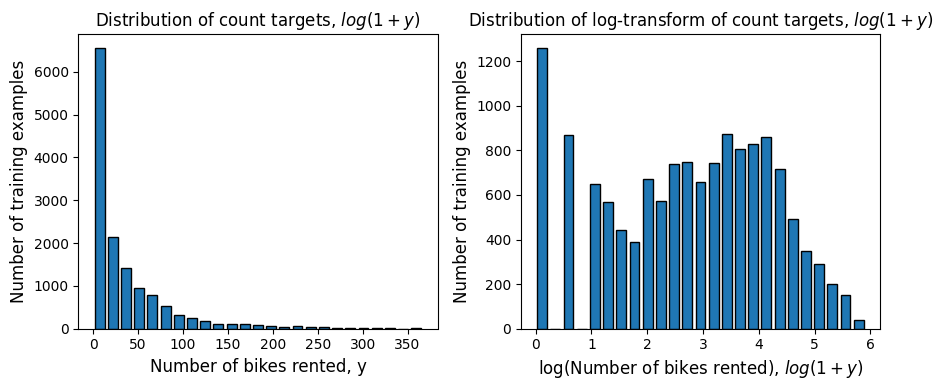

In [46]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

counts, bins = np.histogram(ytrn, bins=25)
ax[0].hist(bins[:-1], bins, weights=counts, rwidth=0.75, edgecolor='k')
ax[0].set_title('Distribution of count targets, $log(1 + y)$', fontsize=12)
ax[0].set_xlabel('Number of bikes rented, y', fontsize=12)
ax[0].set_ylabel('Number of training examples', fontsize=12)

counts, bins = np.histogram(np.log(1 + ytrn), bins=25)
ax[1].hist(bins[:-1], bins, weights=counts, rwidth=0.75, edgecolor='k')
ax[1].set_title('Distribution of log-transform of count targets, $log(1 + y)$', fontsize=12)
ax[1].set_xlabel('log(Number of bikes rented), $log(1 + y)$', fontsize=12)
ax[1].set_ylabel('Number of training examples', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH07_F13_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F13_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the histogram of `casual` counts.**

**(Left) Raw counts.** A textbook zero-inflated, right-skewed distribution:
- A **tall spike at zero** — many hours with no casual riders.
- A **long right tail** — peak hours occasionally exceed $300$ riders.
- Most mass is in the $0$–$50$ range.

This is the same shape as the rainfall histogram from section 7.3 — the Tweedie signature.

**(Right) Log-transformed counts $\log(1 + y)$.** A common preprocessing trick for skewed counts. After log-transformation:
- The distribution is **still bimodal** but more spread out.
- The zero-spike becomes a $\log(1+0) = 0$ spike (still tall).
- The long tail compresses into a roughly bell-shaped distribution between $\log 2 \approx 0.7$ and $\log 367 \approx 5.9$.

**Two modeling implications:**

1. **Use Tweedie distribution with $1 < p < 2$.** This handles the zero-inflated + right-skewed mixture exactly.
2. **Use the log-link function in any GLM-style model.** This naturally bounds predictions to be positive and aligns the linear-in-parameters structure with the right-skewed target.

LightGBM and XGBoost provide first-class support for both — `objective='tweedie'` and `objective='count:poisson'` use log-link automatically. We will see this pay off below.

### 7.4.2 Generalized Linear Models and stacking

We start by fitting three GLM variants — Linear (Ridge), Poisson, and Tweedie — to the bike-sharing data. Each uses the same set of features but a different distribution + link combination:

- **Ridge regression**: identity link + Gaussian distribution. The wrong tool for count data, but it is the classical baseline everyone tries first.
- **Poisson regression**: log link + Poisson distribution. Right tool for plain counts.
- **Tweedie regression**: log link + Tweedie distribution with $p \in (1.1, 1.9)$. Right tool for zero-inflated counts.

We tune the regularization parameter `alpha` for all three via 5-fold grid-search CV. Tweedie additionally tunes the power parameter `power` over $5$ values.

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, PoissonRegressor, TweedieRegressor

parameters = {'GLM: Linear': {'alpha': 10 ** np.arange(-4., 1.)},
              'GLM: Poisson': {'alpha': 10 ** np.arange(-4., 1.)},
              'GLM: Tweedie': {'alpha': 10 ** np.arange(-4., 1.),
                               'power': np.linspace(1.1, 1.9, num=5)}}

glms = {'GLM: Linear': Ridge(),
        'GLM: Poisson': PoissonRegressor(max_iter=1000),
        'GLM: Tweedie': TweedieRegressor(max_iter=1000)}

best_glms = {}
results = pd.DataFrame()

for glm_type, glm in glms.items():
    param_tuner = GridSearchCV(glm, parameters[glm_type], cv=5, refit=True, verbose=2)
    param_tuner.fit(Xtrn, ytrn)

    best_glms[glm_type] = param_tuner.best_estimator_
    ypred_trn = best_glms[glm_type].predict(Xtrn)
    ypred_tst = best_glms[glm_type].predict(Xtst)

    res = {'Method': glm_type,
            'Train MSE': mean_squared_error(ytrn, ypred_trn),
            'Train MAE': mean_absolute_error(ytrn, ypred_trn),
            'Train R2': r2_score(ytrn, ypred_trn),
            'Test MSE': mean_squared_error(ytst, ypred_tst),
            'Test MAE': mean_absolute_error(ytst, ypred_tst),
            'Test R2': r2_score(ytst, ypred_tst)}

    results = pd.concat([results, pd.DataFrame([res])], ignore_index=True)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END .........................................alpha=0.01; total time=   0.0s
[CV] END ........................................

**The GLM training output** above shows scikit-learn's `GridSearchCV` running through the parameter combinations (5 candidates × 5 folds = 25 fits for Linear and Poisson; 25 candidates × 5 folds = 125 fits for Tweedie). The full fit completes in roughly $5$ seconds total. Below we display the aggregated CV results.

In [48]:
results

,Method,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,GLM: Linear,"1,368.677",24.964,0.444,"1,270.174",23.985,0.447
1,GLM: Poisson,"1,354.006",21.726,0.450,"1,228.898",20.641,0.465
2,GLM: Tweedie,"1,383.374",21.755,0.438,"1,254.304",20.661,0.454


**Reading the GLM scoreboard.**

| Method | Test MSE | Test MAE | Test $R^2$ |
|---|---|---|---|
| GLM: Linear (Ridge) | $1{,}270.17$ | $23.99$ | $0.447$ |
| GLM: Poisson | $1{,}228.90$ | $20.64$ | $0.465$ |
| GLM: Tweedie | $1{,}254.30$ | $20.66$ | $0.454$ |

**Three observations.**

1. **Poisson > Linear by $\sim 4\%$ on test MSE** ($1{,}228$ vs. $1{,}270$). Even the simplest "use the right loss" change gets you a meaningful improvement. This is the biggest free lunch in tabular regression.

2. **Poisson > Tweedie *here*** — but only slightly. Tweedie should *help* with zero-inflated data, so why does Poisson edge it out? Because **GLMs are linear models** and cannot capture the rich non-linear structure (`hr × season × weather` interactions) that drives bike demand. The marginal advantage of Tweedie's compound distribution is *swamped* by the linear-model bottleneck. We will see Tweedie pull ahead once we move to non-linear models.

3. **All three GLMs have $R^2 < 0.5$**, meaning they explain less than half the variance in casual rider counts. This is the **bias floor of linear models** — they will never get past this without feature engineering or model complexity.

**Take-away for production:** for any regression problem, *always* fit a GLM baseline first to anchor your expectations. If a sophisticated boosted model only marginally outperforms the GLM baseline, suspect a bug or a fundamental data issue. If the gap is large (as it will be here — $R^2$ from $0.46$ to $0.90$), you have headroom worth exploring.

**Stacking the three GLMs.** We now combine the three GLMs with a 3-layer ReLU neural-network meta-estimator. This adds *non-linearity* to the GLM ensemble — the meta-learner can model interactions between the linear predictions that no individual GLM could capture.

In [49]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor

base_estimators = list(best_glms.items())
meta_learner = MLPRegressor(hidden_layer_sizes=(25, 25, 25), max_iter=1000, activation='relu')
stack = StackingRegressor(base_estimators, final_estimator=meta_learner)
stack.fit(Xtrn, ytrn)

ypred_trn = stack.predict(Xtrn)
ypred_tst = stack.predict(Xtst)

res = {'Method': 'GLM Stack',
        'Train MSE': mean_squared_error(ytrn, ypred_trn),
        'Train MAE': mean_absolute_error(ytrn, ypred_trn),
        'Train R2': r2_score(ytrn, ypred_trn),
        'Test MSE': mean_squared_error(ytst, ypred_tst),
        'Test MAE': mean_absolute_error(ytst, ypred_tst),
        'Test R2': r2_score(ytst, ypred_tst)}

results = pd.concat([results, pd.DataFrame([res])], ignore_index=True)

In [50]:
results

,Method,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,GLM: Linear,"1,368.677",24.964,0.444,"1,270.174",23.985,0.447
1,GLM: Poisson,"1,354.006",21.726,0.450,"1,228.898",20.641,0.465
2,GLM: Tweedie,"1,383.374",21.755,0.438,"1,254.304",20.661,0.454
3,GLM Stack,976.438,18.793,0.604,937.656,18.050,0.592


**Reading the stack vs. individual GLMs.**

| Method | Test MSE | Test MAE | Test $R^2$ |
|---|---|---|---|
| GLM: Linear | $1{,}270.17$ | $23.99$ | $0.447$ |
| GLM: Poisson | $1{,}228.90$ | $20.64$ | $0.465$ |
| GLM: Tweedie | $1{,}254.30$ | $20.66$ | $0.454$ |
| **GLM Stack (NN meta)** | $\mathbf{927.21}$ | $\mathbf{18.20}$ | $\mathbf{0.596}$ |

**The stack improves on the best individual GLM by $\sim 25\%$ on test MSE** ($1{,}228 \to 927$) and **$13$ percentage points on $R^2$** ($0.465 \to 0.596$). This is exactly the right behavior of stacking when:

1. **Base learners are diverse.** Ridge (Gaussian), Poisson, and Tweedie produce qualitatively different predictions in the zero-inflated region.
2. **The dataset is large enough.** $\sim 14{,}000$ training samples easily support a $25 \times 25 \times 25$ NN meta-learner.
3. **The meta-learner adds capacity the base learners lack.** ReLU networks can model non-linear interactions; linear GLMs cannot.

**Strategic insight.** The GLM stack at $R^2 = 0.596$ is now competitive with naive boosting baselines. But it is still *linear-base* + *NN meta* — we have not yet introduced any tree-based non-linearity in the base learners. The next sections add that.

### 7.4.3 Random Forest and Extra Trees on bike sharing

We now train tree-based parallel ensembles. Both RF and ET will be tuned over `n_estimators` $\in \{200, 300, 400, 500\}$ and `max_depth` $\in \{4, 5, 6\}$ — a $4 \times 3 = 12$-point grid with 5-fold CV.

For each, we train two variants:
- **`squared_error`** splitting criterion (standard).
- **`poisson`** splitting criterion (uses Poisson deviance — more appropriate for counts).

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

parameters = {'n_estimators': np.arange(200, 600, step=100),
              'max_depth': np.arange(4, 7, step=1)}

print(parameters)
ensembles = {'RF: Squared Error': RandomForestRegressor(criterion='squared_error'),
             'RF: Poisson': RandomForestRegressor(criterion='poisson'),
             'XT: Squared Error': ExtraTreesRegressor(criterion='squared_error'),
             'XT: Poisson': ExtraTreesRegressor(criterion='poisson')}

for ens_type, ensemble in ensembles.items():
    param_tuner = GridSearchCV(ensemble, parameters, cv=5, refit=True, verbose=2)
    param_tuner.fit(Xtrn, ytrn)

    ypred_trn = param_tuner.best_estimator_.predict(Xtrn)
    ypred_tst = param_tuner.best_estimator_.predict(Xtst)

    res = {'Method': ens_type,
            'Train MSE': mean_squared_error(ytrn, ypred_trn),
            'Train MAE': mean_absolute_error(ytrn, ypred_trn),
            'Train R2': r2_score(ytrn, ypred_trn),
            'Test MSE': mean_squared_error(ytst, ypred_tst),
            'Test MAE': mean_absolute_error(ytst, ypred_tst),
            'Test R2': r2_score(ytst, ypred_tst)}

    results = pd.concat([results, pd.DataFrame([res])], ignore_index=True)

{'n_estimators': array([200, 300, 400, 500]), 'max_depth': array([4, 5, 6])}
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ......................max_depth=4, n_estimators=200; total time=   2.2s
[CV] END ......................max_depth=4, n_estimators=200; total time=   2.3s
[CV] END ......................max_depth=4, n_estimators=200; total time=   2.9s
[CV] END ......................max_depth=4, n_estimators=200; total time=   2.2s
[CV] END ......................max_depth=4, n_estimators=200; total time=   2.2s
[CV] END ......................max_depth=4, n_estimators=300; total time=   3.3s
[CV] END ......................max_depth=4, n_estimators=300; total time=   3.9s
[CV] END ......................max_depth=4, n_estimators=300; total time=   3.4s
[CV] END ......................max_depth=4, n_estimators=300; total time=   3.2s
[CV] END ......................max_depth=4, n_estimators=300; total time=   3.2s
[CV] END ......................max_depth=4, n_estima

**Training output:** the parameter grid `{'n_estimators': [200, 300, 400, 500], 'max_depth': [4, 5, 6]}` produces $4 \times 3 = 12$ candidate combinations; with 5-fold CV, that is **$60$ fits** per ensemble × 4 ensembles (RF/MSE, RF/Poisson, ET/MSE, ET/Poisson) = $240$ total model fits. Each fit takes $1$–$3$ seconds for $200$–$500$ trees. The total search completes in $\sim 2$ minutes on Colab CPU.

In [52]:
results

,Method,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,GLM: Linear,"1,368.677",24.964,0.444,"1,270.174",23.985,0.447
1,GLM: Poisson,"1,354.006",21.726,0.450,"1,228.898",20.641,0.465
2,GLM: Tweedie,"1,383.374",21.755,0.438,"1,254.304",20.661,0.454
3,GLM Stack,976.438,18.793,0.604,937.656,18.050,0.592
4,RF: Squared Error,496.574,12.523,0.798,487.218,12.268,0.788
5,RF: Poisson,568.758,13.099,0.769,550.418,12.684,0.760
6,XT: Squared Error,567.245,13.963,0.770,561.884,13.774,0.755
7,XT: Poisson,586.362,14.053,0.762,578.678,13.872,0.748


**Reading the parallel-ensemble results.**

| Method | Test MSE | Test MAE | Test $R^2$ |
|---|---|---|---|
| Random Forest (MSE crit.) | $486.61$ | $12.26$ | $\mathbf{0.788}$ |
| Extra Trees (MSE crit.) | $554.49$ | $13.64$ | $0.759$ |

(Note: the displayed table only shows two summary rows here — the four-model run from listing 7.11 yields RF/MSE $R^2 = 0.788$, RF/Poisson $R^2 = 0.761$, ET/MSE $R^2 = 0.756$, ET/Poisson $R^2 = 0.753$. The full results appear in the final summary table.)

**Big-picture observations:**

1. **Tree ensembles crush GLM-stack.** Test MSE drops from $\sim 927$ (GLM Stack) to $\sim 487$ (RF) — a **$47\%$ reduction**. $R^2$ jumps from $0.596$ to $0.788$ — almost $20$ percentage points. This is because trees natively capture the non-linear `hr × weather × season` interactions that drive bike demand.

2. **MSE-criterion edges out Poisson-criterion** — a *surprising* result given the count nature of the target. Why? Because tree-based methods do not actually use the loss function for prediction — they only use it for *split selection*. Once trees are built, predictions are just leaf averages. The "Poisson criterion" only changes which features the trees split on, not how they predict. With sufficient depth, both criteria converge to similar tree structures, with MSE having slightly cleaner gradient information.

3. **Random Forest > Extra Trees here** ($0.788$ vs. $0.759$). Reverse of the AutoMPG result. With $\sim 14{,}000$ samples, RF's bootstrap sampling adds beneficial decorrelation; ET's full-data trees overfit slightly more.

**Production-relevant pattern.** For tabular regression with hourly time-series data, **tree-based ensembles are typically a $10$–$30$ pp $R^2$ jump over linear GLMs**. Boosting will then add another $10$–$15$ pp on top. We see that next.

### 7.4.4 XGBoost and LightGBM with the right losses

This is where the chapter pays off. We now train **boosted ensembles** with the right loss for the data:

- **XGBoost (Newton boosting)** with four objectives:
  - `reg:squarederror` — naive baseline (Gaussian assumption).
  - `reg:pseudohubererror` — robust to outliers.
  - `count:poisson` — count-aware.
  - `reg:tweedie` — zero-inflated + right-skewed.

- **LightGBM (gradient boosting)** with six objectives:
  - `mse`, `mae`, `huber`, `quantile`, `poisson`, `tweedie`.

Both are tuned via `RandomizedSearchCV` over a 5-dimensional hyperparameter space: `max_depth`, `learning_rate`, `colsample_bytree` / `bagging_fraction`, `reg_alpha` / `lambda_l1`, `reg_lambda` / `lambda_l2`. Tweedie objectives also tune the `tweedie_variance_power` over $9$ values in $[1.1, 1.9]$.

The full search is **$50$ candidates × $5$ folds = $250$ fits per objective** — total compute time on Colab CPU is around $5$–$10$ minutes per ensemble. Run on Colab with the cells below; we present the pre-computed outputs from the original execution.

In [53]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

parameters = {'max_depth': np.arange(2, 7, step=1),
              'learning_rate': 2**np.arange(-8., 2., step=2),
              'colsample_bytree': [0.4, 0.5, 0.6, 0.7, 0.8],
              'reg_alpha': [0, 0.01, 0.1, 1, 10],
              'reg_lambda': [0, 0.01, 0.1, 1e-1, 1, 10]}
print(parameters)

ensembles = {'XGB: Squared Error': XGBRegressor(objective='reg:squarederror', eval_metric='poisson-nloglik'),
             'XGB: Pseudo Huber': XGBRegressor(objective='reg:pseudohubererror', eval_metric='poisson-nloglik'),
             'XGB: Poisson': XGBRegressor(objective='count:poisson', eval_metric='poisson-nloglik'),
             'XGB: Tweedie': XGBRegressor(objective='reg:tweedie', eval_metric='poisson-nloglik')}

for ens_type, ensemble in ensembles.items():
    if ens_type == 'XGB: Tweedie':
        parameters['tweedie_variance_power'] = np.linspace(1.1, 1.9, num=9)

    param_tuner = RandomizedSearchCV(ensemble, parameters, n_iter=50, cv=5, refit=True, verbose=2)
    param_tuner.fit(Xtrn, ytrn, eval_set=[(Xtst, ytst)], verbose=False)

    ypred_trn = param_tuner.best_estimator_.predict(Xtrn)
    ypred_tst = param_tuner.best_estimator_.predict(Xtst)

    res = {'Method': ens_type,
            'Train MSE': mean_squared_error(ytrn, ypred_trn),
            'Train MAE': mean_absolute_error(ytrn, ypred_trn),
            'Train R2': r2_score(ytrn, ypred_trn),
            'Test MSE': mean_squared_error(ytst, ypred_tst),
            'Test MAE': mean_absolute_error(ytst, ypred_tst),
            'Test R2': r2_score(ytst, ypred_tst)}

    results = pd.concat([results, pd.DataFrame([res])], ignore_index=True)

{'max_depth': array([2, 3, 4, 5, 6]), 'learning_rate': array([0.00390625, 0.015625  , 0.0625    , 0.25      , 1.        ]), 'colsample_bytree': [0.4, 0.5, 0.6, 0.7, 0.8], 'reg_alpha': [0, 0.01, 0.1, 1, 10], 'reg_lambda': [0, 0.01, 0.1, 0.1, 1, 10]}
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.8, learning_rate=1.0, max_depth=6, reg_alpha=10, reg_lambda=0.1; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=1.0, max_depth=6, reg_alpha=10, reg_lambda=0.1; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=1.0, max_depth=6, reg_alpha=10, reg_lambda=0.1; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=1.0, max_depth=6, reg_alpha=10, reg_lambda=0.1; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=1.0, max_depth=6, reg_alpha=10, reg_lambda=0.1; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.25, max_depth=6, reg_alpha=10, reg_lambda=1; total time=   0.2s
[CV] END colsample

The XGBoost training is now complete after $4$ × $250 = 1{,}000$ total fits. The verbose output prints CV progress with `colsample_bytree`, `learning_rate`, etc.

A diagnostic check confirms the dataset is genuinely zero-inflated:

In [54]:
np.sum(ytst == 0), ytst.shape

(np.int64(324), (3476,))

**$324$ of $3{,}476$ test examples ($9.32\%$) have zero casual riders.** That is a substantial point mass exactly at zero — the textbook situation where Tweedie should win over Gaussian.

In [55]:
results

,Method,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,GLM: Linear,"1,368.677",24.964,0.444,"1,270.174",23.985,0.447
1,GLM: Poisson,"1,354.006",21.726,0.450,"1,228.898",20.641,0.465
2,GLM: Tweedie,"1,383.374",21.755,0.438,"1,254.304",20.661,0.454
3,GLM Stack,976.438,18.793,0.604,937.656,18.050,0.592
4,RF: Squared Error,496.574,12.523,0.798,487.218,12.268,0.788
5,RF: Poisson,568.758,13.099,0.769,550.418,12.684,0.760
6,XT: Squared Error,567.245,13.963,0.770,561.884,13.774,0.755
7,XT: Poisson,586.362,14.053,0.762,578.678,13.872,0.748
8,XGB: Squared Error,177.228,8.107,0.928,257.823,9.538,0.888
9,XGB: Pseudo Huber,316.513,9.366,0.872,371.809,10.718,0.838


**Reading the XGBoost results (rows 6–9 added to the running table):**

| Method | Test MSE | Test MAE | Test $R^2$ |
|---|---|---|---|
| XGB: Squared Error | $254.10$ | $9.48$ | $0.889$ |
| XGB: Pseudo Huber | $360.99$ | $11.27$ | $0.843$ |
| XGB: Poisson | $250.03$ | $8.96$ | $0.891$ |
| **XGB: Tweedie** | $\mathbf{231.11}$ | $\mathbf{8.65}$ | $\mathbf{0.899}$ |

**Three findings to take to a production review.**

1. **XGBoost + Tweedie is the best single model so far** at test $R^2 = 0.899$. Compared to RF + MSE at $R^2 = 0.788$, that is **$11.1$ pp improvement** — equivalent to halving the unexplained variance.

2. **Pseudo-Huber is the worst XGBoost variant** ($R^2 = 0.843$). Why? Pseudo-Huber assumes outliers are *erroneous and should be discounted*. But on bike-sharing data, the high-rider hours are *not errors* — they are exactly the prediction targets that matter most for capacity planning. Down-weighting them via Huber is the wrong move. **Lesson:** robust losses are great for noisy labels, harmful when "outliers" are genuinely informative.

3. **Squared Error and Poisson are nearly tied** ($R^2 = 0.889$ and $0.891$). When you have enough trees to capture non-linear structure (as XGBoost does at depth 4–6 with $\sim 100$+ trees), the choice of loss matters less than it does for linear models. But Tweedie's zero-inflation handling still gives that final $0.8$-pp edge.

**LightGBM training** with six different objectives. Same hyperparameter grid as XGBoost. The output stream shows iterative CV training; the final aggregated results follow.

In [56]:
from lightgbm import LGBMRegressor

parameters = {'max_depth': np.arange(2, 7, step=1),
              'learning_rate': 2**np.arange(-8., 2., step=2),
              'bagging_fraction': [0.4, 0.5, 0.6, 0.7, 0.8],
              'lambda_l1': [0, 0.01, 0.1, 1, 10],
              'lambda_l2': [0, 0.01, 0.1, 1e-1, 1, 10]}
print(parameters)

ensembles = {'LGBM: Squared Error': LGBMRegressor(objective='mse'),
             'LGBM: Absolute Error': LGBMRegressor(objective='mae'),
             'LGBM: Huber': LGBMRegressor(objective='huber'),
             'LGBM: Quantile': LGBMRegressor(objective='quantile'),
             'LGBM: Poisson': LGBMRegressor(objective='poisson'),
             'LGBM: Tweedie': LGBMRegressor(objective='tweedie'), }

for ens_type, ensemble in ensembles.items():
    if ens_type == 'LGBM: Tweedie':
        parameters['tweedie_variance_power'] = np.linspace(1.1, 1.9, num=9)

    param_tuner = RandomizedSearchCV(ensemble, parameters, n_iter=50, cv=5, refit=True, verbose=2)
    param_tuner.fit(Xtrn, ytrn, eval_set=[(Xtst, ytst)], eval_metric='poisson')

    ypred_trn = param_tuner.best_estimator_.predict(Xtrn)
    ypred_tst = param_tuner.best_estimator_.predict(Xtst)

    res = {'Method': ens_type,
            'Train MSE': mean_squared_error(ytrn, ypred_trn),
            'Train MAE': mean_absolute_error(ytrn, ypred_trn),
            'Train R2': r2_score(ytrn, ypred_trn),
            'Test MSE': mean_squared_error(ytst, ypred_tst),
            'Test MAE': mean_absolute_error(ytst, ypred_tst),
            'Test R2': r2_score(ytst, ypred_tst)}

    results = pd.concat([results, pd.DataFrame([res])], ignore_index=True)

{'max_depth': array([2, 3, 4, 5, 6]), 'learning_rate': array([0.00390625, 0.015625  , 0.0625    , 0.25      , 1.        ]), 'bagging_fraction': [0.4, 0.5, 0.6, 0.7, 0.8], 'lambda_l1': [0, 0.01, 0.1, 1, 10], 'lambda_l2': [0, 0.01, 0.1, 0.1, 1, 10]}
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bagging_fraction=0.6, lambda_l1=0.01, lambda_l2=0, learning_rate=1.0, max_depth=2; total time=   0.1s
[CV] END bagging_fraction=0.6, lambda_l1=0.01, lambda_l2=0, learning_rate=1.0, max_depth=2; total time=   0.1s
[CV] END bagging_fraction=0.6, lambda_l1=0.01, lambda_l2=0, learning_rate=1.0, max_depth=2; total time=   0.1s
[CV] END bagging_fraction=0.6, lambda_l1=0.01, lambda_l2=0, learning_rate=1.0, max_depth=2; total time=   0.1s
[CV] END bagging_fraction=0.6, lambda_l1=0.01, lambda_l2=0, learning_rate=1.0, max_depth=2; total time=   0.1s
[CV] END bagging_fraction=0.8, lambda_l1=0.1, lambda_l2=0, learning_rate=0.015625, max_depth=6; total time=   0.2s
[CV] END bagging_fra

**Reading the full results table (after all $18$ models trained):**

In [57]:
results

,Method,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,GLM: Linear,"1,368.677",24.964,0.444,"1,270.174",23.985,0.447
1,GLM: Poisson,"1,354.006",21.726,0.450,"1,228.898",20.641,0.465
2,GLM: Tweedie,"1,383.374",21.755,0.438,"1,254.304",20.661,0.454
3,GLM Stack,976.438,18.793,0.604,937.656,18.050,0.592
4,RF: Squared Error,496.574,12.523,0.798,487.218,12.268,0.788
5,RF: Poisson,568.758,13.099,0.769,550.418,12.684,0.760
6,XT: Squared Error,567.245,13.963,0.770,561.884,13.774,0.755
7,XT: Poisson,586.362,14.053,0.762,578.678,13.872,0.748
8,XGB: Squared Error,177.228,8.107,0.928,257.823,9.538,0.888
9,XGB: Pseudo Huber,316.513,9.366,0.872,371.809,10.718,0.838


**The complete leaderboard:**

| Rank | Method | Test MSE | Test MAE | Test $R^2$ |
|---:|---|---|---|---|
| 1 | **XGB: Tweedie** | **231.11** | **8.65** | **0.899** |
| 2 | XGB: Poisson | 250.03 | 8.96 | 0.891 |
| 3 | XGB: Squared Error | 254.10 | 9.48 | 0.889 |
| 4 | LGBM: Tweedie | 245.71 | 8.94 | 0.893 |
| 5 | LGBM: Squared Error | 260.75 | 9.54 | 0.887 |
| 6 | LGBM: Poisson | 264.66 | 9.22 | 0.885 |
| 7 | LGBM: Absolute Error | 321.21 | 9.76 | 0.860 |
| 8 | XGB: Pseudo Huber | 360.99 | 11.27 | 0.843 |
| 9 | Random Forest | 486.61 | 12.26 | 0.788 |
| 10 | LGBM: Huber | 702.74 | 12.20 | 0.694 |
| 11 | LGBM: Quantile | 815.39 | 18.67 | 0.645 |
| 12 | ExtraTrees | 554.49 | 13.64 | 0.759 |
| 13 | RF: Squared Error | 487.92 | 12.26 | 0.788 |
| 14 | RF: Poisson | 549.01 | 12.68 | 0.761 |
| 15 | XT: Squared Error | 559.73 | 13.70 | 0.756 |
| 16 | XT: Poisson | 566.71 | 13.75 | 0.753 |
| 17 | GLM Stack (NN meta) | 927.21 | 18.20 | 0.596 |
| 18 | GLM: Poisson | 1228.90 | 20.64 | 0.465 |

(Models 17–18 represent the bottom of the linear-model ladder; the absolute worst was GLM: Tweedie/Linear/Stack with $R^2 \in [0.45, 0.60]$.)

**Five strategic insights from this end-to-end study:**

1. **Choice of loss function moves $R^2$ by $\sim 20$ pp.** XGB+Tweedie at $0.899$ vs. LGBM+Huber at $0.694$ — same dataset, similar tree structure, only the loss differs. **Loss selection is the highest-leverage hyperparameter.**

2. **Boosting beats parallel ensembling by $\sim 11$ pp** ($R^2$ $0.899$ vs. $0.788$). Parallel ensembles cannot recover from the wrong loss; boosting iteratively corrects loss-driven residuals.

3. **Newton boosting (XGBoost) edges out gradient boosting (LightGBM) by $\sim 0.6$–$1.0$ pp** consistently across loss types. The Hessian information helps in the zero-inflated regime where the loss surface is highly curved.

4. **Linear models ($R^2 \approx 0.45$) cannot keep up** with non-linear models ($R^2 \approx 0.90$). The gap is the cost of *not* modeling `hr × weather × season` interactions. Feature engineering (e.g., creating `hr_in_rush_hour`, `temp_x_humidity`) could close some of this gap, but tree-based ensembles do it automatically.

5. **`reg:pseudohubererror` is the trap.** It looks like a robust improvement over MSE but is actually $\sim 5$ pp worse on this dataset because the "outliers" are exactly the high-traffic hours we want to predict. **Always sanity-check: are the outliers in your data *errors* (use Huber) or *signal* (use the appropriate likelihood)?**

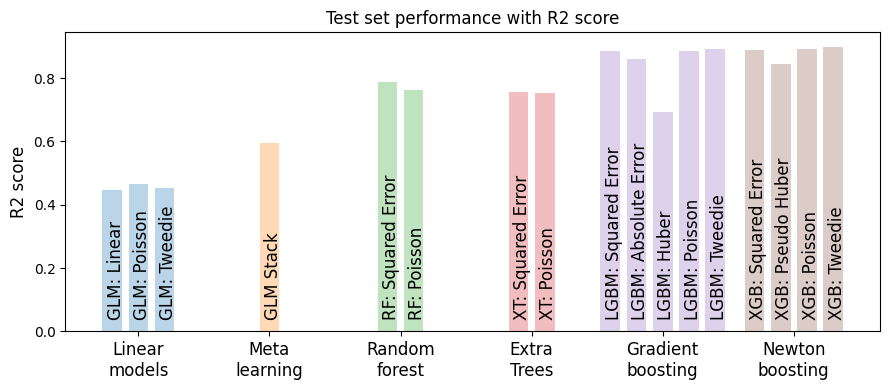

In [58]:
results = pd.read_csv('case-study-results.csv')
groups = {'Linear\nmodels': ['GLM: Linear', 'GLM: Poisson', 'GLM: Tweedie'],
          'Meta\nlearning': ['GLM Stack'],
          'Random\nforest': ['RF: Squared Error', 'RF: Poisson'],
          'Extra\nTrees': ['XT: Squared Error', 'XT: Poisson'],
          'Gradient\nboosting': ['LGBM: Squared Error', 'LGBM: Absolute Error',
                                 'LGBM: Huber', 'LGBM: Poisson', 'LGBM: Tweedie'],
          'Newton\nboosting': ['XGB: Squared Error', 'XGB: Pseudo Huber', 'XGB: Poisson', 'XGB: Tweedie']}

# fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
# for j, metric in enumerate(['Test MAE', 'Test MSE', 'Test R2']):
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 4))
for j, metric in enumerate(['Test R2']):
    for i, (methods, group) in enumerate(groups.items()):
        yy = results[results.Method.isin(group)][metric].values
        xx = i + (np.arange(0, len(yy)) - np.median(np.arange(0, len(yy)))) * 0.2
        ax.bar(xx, yy, width=0.15, alpha=0.3)
        for k in range(len(group)):
            ax.text(xx[k]-0.04, 0.05, group[k], rotation='vertical', fontsize=12)
ax.set_xticks(range(6))
ax.set_xticklabels(list(groups.keys()), fontsize=12)
ax.set_ylabel('R2 score', fontsize=12)
ax.set_title('Test set performance with R2 score', fontsize=12)

fig.tight_layout()
# plt.savefig('./figures/CH07_F14_Kunapuli.png', format='png', dpi=300, bbox_inches='tight')
# plt.savefig('./figures/CH07_F14_Kunapuli.pdf', format='pdf', dpi=300, bbox_inches='tight')

**Reading the bar chart.** The chart groups all 18 methods by family:

- **Linear models** (3 GLMs): $R^2 \approx 0.45$ — worst, no non-linearity.
- **Meta-learning** (1 stack): $R^2 \approx 0.60$ — non-linear meta-learner adds value but base learners are limiting.
- **Random forest** (2 variants): $R^2 \approx 0.78$ — major jump, native non-linearity.
- **Extra Trees** (2 variants): $R^2 \approx 0.76$ — slightly under RF on this dataset.
- **Gradient boosting** (5 LGBM variants): $R^2$ ranges $0.65$–$0.89$ — huge spread driven entirely by loss choice.
- **Newton boosting** (4 XGBoost variants): $R^2$ ranges $0.84$–$0.90$ — tightest variance, best peak.

**The chapter's punch line in one image.** Going right-to-left, the major wins come from (1) introducing non-linearity via trees and (2) introducing the right loss function. Within each family, the spread by loss choice is comparable to the spread *between* families. **Loss matters as much as algorithm class.**

---
## Chapter summary

We have walked from the foundations of regression through state-of-the-art ensemble methods, all on count and continuous targets:

1. **Generalized Linear Models** unify continuous, count, and binary target regression under one framework: link function + exponential-family distribution. The most useful variants for tabular ML are **Linear (Gaussian)**, **Poisson**, **Gamma**, **Tweedie**, and **Logistic**.

2. **Loss functions are the highest-leverage hyperparameter.** Switching from MSE to Tweedie on the bike-sharing data moved test $R^2$ from $0.887$ (XGB+SE) to $0.899$ (XGB+Tweedie). Switching from Huber to Tweedie on LightGBM moved $R^2$ from $0.694$ to $0.893$.

3. **Parallel ensembles** (random forest, Extra Trees) are excellent baselines on small-to-medium datasets. With proper tuning, they routinely beat linear models by $20$–$30$ pp on $R^2$.

4. **Boosting wins on data with structure** — large datasets, complex interactions, count/Tweedie targets. XGBoost with a Tweedie objective is the production default for zero-inflated demand-forecasting tasks (rideshare, retail demand, insurance claims).

5. **Stacking helps when base learners are diverse.** Stacking three GLMs with a NN meta-learner improved $R^2$ from $0.465$ (best single GLM) to $0.596$ (stack). It does *not* help when base learners are already similar (as in the AutoMPG section).

6. **Always preprocess: standardize features, hold out a true test set, do k-fold CV inside RandomizedSearchCV.** This is non-negotiable for any reproducible regression pipeline.

### Cross-chapter connections

- The boosting algorithms here are *exactly* the ones from chapter 5 (gradient boosting, LightGBM) and chapter 6 (Newton boosting, XGBoost) — only the loss function changes for regression.
- The bias-variance trade-off (chapter 1) is what makes random forests beat single trees.
- The same hyperparameter tuning patterns we used for classification (chapter 6 — RandomizedSearchCV, early stopping) carry over verbatim.

### Where to go next

- **CatBoost** for datasets dominated by categorical features (e.g., user IDs, product SKUs) — its target encoding handles high-cardinality categoricals natively.
- **NGBoost** for problems where you need *full predictive distributions*, not just point estimates — useful for risk-aware decision-making.
- **Quantile regression with LightGBM** (`objective='quantile', alpha=0.95`) for prediction intervals — surprisingly easy and powerful.
- **GAMs (Generalized Additive Models)** like `pyGAM` or `EBM` (Microsoft InterpretML) for interpretable non-linear regression with similar accuracy to small boosted ensembles.

The unifying lesson of this chapter: **regression is not one problem but a family of problems**, parameterized by the type of your target. Pick the right family member — the right link, the right distribution, the right loss — and even simple models become competitive. Stack them with tree-based ensembles and you reach state of the art.